## 1.1 Data Fields

In [1]:
import pandas as pd

df = pd.read_csv('logbook_assignment1.csv', low_memory=False)
print(f"Initial rows: {len(df)}")

Initial rows: 1174870


#### 1.1.1 Percentage of date_fueled entries that are not proper dates
And
#### 1.1.3 Convert the column to a date format, setting any invalid date fueled entries to NaT

In [2]:
parsed_dates = pd.to_datetime(df['date_fueled'], format='%b %d %Y', errors='coerce')
invalid_count = parsed_dates.isna().sum()
invalid_percent = (invalid_count / len(df)) * 100
print(f"Missing date_fueled entries: {invalid_count} ({invalid_percent:.2f}%)")

Missing date_fueled entries: 137210 (11.68%)


#### 1.1.2 Where date_fueled is invalid but date_captured is valid, use date_captured as a proxy
And
#### 1.1.3 Convert the column to a date format, setting any invalid date captured entries to NaT

In [3]:
parsed_captured = pd.to_datetime(df['date_captured'], format='%b %d %Y', errors='coerce')
needs_proxy = parsed_dates.isna() & parsed_captured.notna()
parsed_dates.loc[needs_proxy] = parsed_captured.loc[needs_proxy]
print(f"Rows filled using date_captured as proxy: {needs_proxy.sum()}")
print(f"Remaining missing after proxy fill: {parsed_dates.isna().sum()}")

Rows filled using date_captured as proxy: 137210
Remaining missing after proxy fill: 0


#### Assign the cleaned column back

In [4]:
df['date_fueled'] = parsed_dates
df['date_captured'] = parsed_captured
print(f"date_fueled dtype: {df['date_fueled'].dtype}")
print(f"Missing date_fueled after proxy fill: {df['date_fueled'].isna().sum()}")

date_fueled dtype: datetime64[ns]
Missing date_fueled after proxy fill: 0


#### 1.1.4 Remove dates in the future or earlier than 2005

In [5]:
today = pd.Timestamp.today()
before_count = len(df)

out_of_range = (df['date_fueled'] > today) | (df['date_fueled'] < pd.Timestamp('2005-01-01'))
print(f"Rows with out-of-range dates: {out_of_range.sum()}")

df = df[~out_of_range]
print(f"Rows before: {before_count}, after: {len(df)}")

Rows with out-of-range dates: 570
Rows before: 1174870, after: 1174300


### Plot the distribution of fueling dates

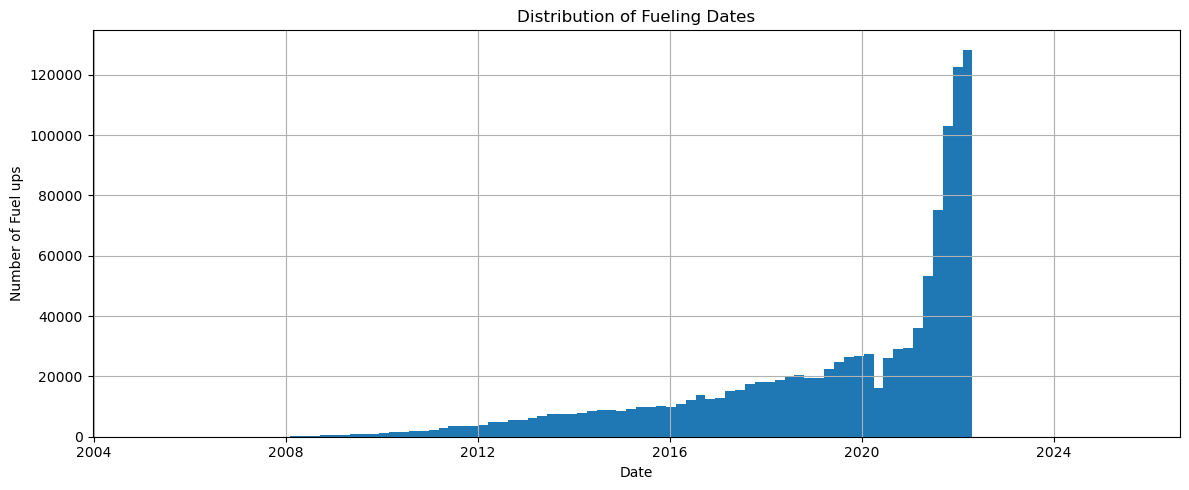

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
df['date_fueled'].dropna().hist(bins=100, ax=ax)
ax.set_title('Distribution of Fueling Dates')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Fuel ups')
plt.tight_layout()
plt.show()

## 1.2 Numeric Fields
#### 1.2.1 Missing % on raw gallons/miles/odometer, before conversion

In [9]:
total_rows = len(df)
print("before conversion:")
for col in ['gallons', 'miles', 'odometer']:
    missing = df[col].isna().sum()
    percent = (missing / total_rows) * 100
    print(f"{col}: {missing} missing ({percent:.2f}%)")

before conversion:
gallons: 74171 missing (6.32%)
miles: 1028143 missing (87.55%)
odometer: 149037 missing (12.69%)


#### 1.2.3 Convert to float (strip commas/whitespace first)

In [10]:
numeric_cols = ['gallons', 'miles', 'odometer', 'mpg']
for col in numeric_cols:
    df[col] = (
        df[col].astype(str)
        .str.strip()
        .str.replace(',', '', regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')
print(f"types after conversion:\n{df[numeric_cols].dtypes}")

types after conversion:
gallons     float64
miles       float64
odometer    float64
mpg         float64
dtype: object


### Missing % after conversion

In [11]:
print("after conversion:")
for col in ['gallons', 'miles', 'odometer']:
    missing = df[col].isna().sum()
    percent = (missing / total_rows) * 100
    print(f"{col}: {missing} missing ({percent:.2f}%)")

after conversion:
gallons: 74171 missing (6.32%)
miles: 1028143 missing (87.55%)
odometer: 149037 missing (12.69%)


#### 1.2.2 Fill missing values using miles-gallons-mpg interdependency

In [12]:
before = {col: df[col].isna().sum() for col in ['gallons', 'miles', 'mpg']}

can_fill_miles = df['miles'].isna() & df['gallons'].notna() & df['mpg'].notna() & (df['mpg'] != 0)
df.loc[can_fill_miles, 'miles'] = df.loc[can_fill_miles, 'gallons'] * df.loc[can_fill_miles, 'mpg']

can_fill_gallons = df['gallons'].isna() & df['miles'].notna() & df['mpg'].notna() & (df['mpg'] != 0)
df.loc[can_fill_gallons, 'gallons'] = df.loc[can_fill_gallons, 'miles'] / df.loc[can_fill_gallons, 'mpg']

can_fill_mpg = df['mpg'].isna() & df['miles'].notna() & df['gallons'].notna() & (df['gallons'] != 0)
df.loc[can_fill_mpg, 'mpg'] = df.loc[can_fill_mpg, 'miles'] / df.loc[can_fill_mpg, 'gallons']

after = {col: df[col].isna().sum() for col in ['gallons', 'miles', 'mpg']}

print("Fill results:")
for col in ['gallons', 'miles', 'mpg']:
    filled = before[col] - after[col]
    print(f"{col}: filled {filled} values ({before[col]} -> {after[col]} missing)")

Fill results:
gallons: filled 0 values (74171 -> 74171 missing)
miles: filled 819235 values (1028143 -> 208908 missing)
mpg: filled 0 values (74171 -> 74171 missing)


### Plot distributions

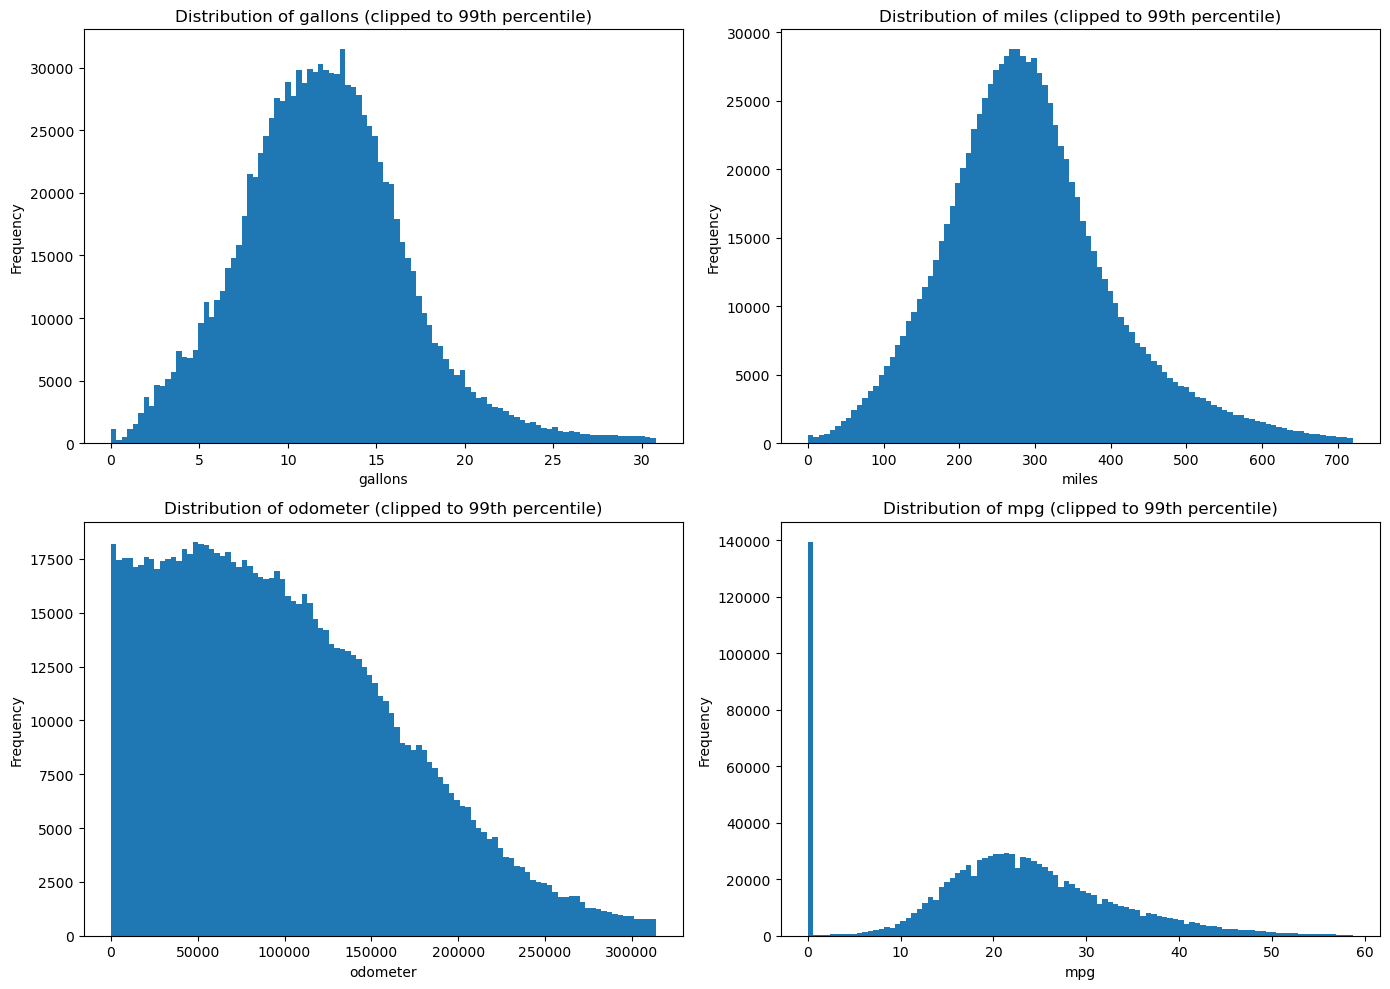

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), ['gallons', 'miles', 'odometer', 'mpg']):
    data = df[col].dropna()
    upper = data.quantile(0.99)
    ax.hist(data[data <= upper], bins=100)
    ax.set_title(f'Distribution of {col} (clipped to 99th percentile)')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### Statistical description

In [14]:
stats_cols = ['gallons', 'miles', 'odometer', 'mpg']
desc = df[stats_cols].describe()
modes = df[stats_cols].mode().iloc[0]
desc.loc['mode'] = modes
print("Statistical description")
print(desc)

Statistical description
            gallons          miles      odometer           mpg
count  1.100129e+06  965392.000000  1.025263e+06  1.100129e+06
mean   1.279743e+01     307.060698  1.040011e+05  2.216302e+01
std    7.448279e+01     767.267612  3.405976e+05  1.574435e+01
min    0.000000e+00       0.000000  0.000000e+00  0.000000e+00
25%    8.990000e+00     219.307500  4.592400e+04  1.560000e+01
50%    1.195400e+01     283.949900  9.188800e+04  2.180000e+01
75%    1.493900e+01     355.423025  1.469255e+05  2.850000e+01
max    2.838000e+04  195321.200000  2.543621e+08  1.214300e+03
mode   1.056700e+01     300.000000  1.000000e+00  0.000000e+00


### Converting the rest for memory's sake

In [15]:
#cost_per_gallon and total_spent left as strings for now
print(f"cost_per_gallon dtype: {df['cost_per_gallon'].dtype}")
print(f"total_spent dtype:     {df['total_spent'].dtype}")
print("")

#Downcast already numeric measurement columns to float32
float_cols = ['odometer', 'miles', 'gallons', 'mpg']
print(f"Memory before float32 downcast: {df[float_cols].memory_usage(deep=True).sum() / 1024**2:.2f} MB")
for col in float_cols:
    df[col] = df[col].astype('float32')
print(f"Memory after float32 downcast:  {df[float_cols].memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("")

#user_url as categorical
print(f"BEFORE user_url conversion: memory = {df['user_url'].memory_usage(deep=True) / 1024**2:.2f} MB")
df['user_url'] = df['user_url'].astype('category')
print(f"AFTER user_url conversion:  memory = {df['user_url'].memory_usage(deep=True) / 1024**2:.2f} MB")
print("")

#Final summary
print(f"\nFINAL dtypes:\n{df.dtypes}")
print(f"\nFINAL missing values:\n{df.isna().sum()}")
print(f"\nFINAL total memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

cost_per_gallon dtype: object
total_spent dtype:     object

Memory before float32 downcast: 44.80 MB
Memory after float32 downcast:  26.88 MB

BEFORE user_url conversion: memory = 123.44 MB
AFTER user_url conversion:  memory = 29.19 MB


FINAL dtypes:
date_fueled        datetime64[ns]
date_captured      datetime64[ns]
odometer                  float32
gallons                   float32
cost_per_gallon            object
total_spent                object
mpg                       float32
miles                     float32
user_url                 category
dtype: object

FINAL missing values:
date_fueled             0
date_captured           0
odometer           149037
gallons             74171
cost_per_gallon     80719
total_spent         74171
mpg                 74171
miles              208908
user_url                0
dtype: int64

FINAL total memory: 191.67 MB


## 2 Feature Engineering

#### 2.1.1 Create a new column with the currency.
#### 2.1.2 Extracting currency and cost per gallon

In [16]:
for col in ['cost_per_gallon', 'total_spent']:
    extracted = df[col].astype(str).str.extract(r'^([^\d]*)([\d,]+\.?\d*)')
    
    currency = extracted[0].str.strip()
    currency = currency.replace('', pd.NA)
    
    amount = extracted[1].str.replace(',', '', regex=False)
    amount = pd.to_numeric(amount, errors='coerce')
    
    df[f'{col}_currency'] = currency.astype('category')
    df[f'{col}_value'] = amount.astype('float32')

print(df[['cost_per_gallon', 'cost_per_gallon_currency', 'cost_per_gallon_value',
          'total_spent', 'total_spent_currency', 'total_spent_value']].head(10))

  cost_per_gallon cost_per_gallon_currency  cost_per_gallon_value total_spent  \
0             NaN                      NaN                    NaN         NaN   
1          $5.599                        $                  5.599      $67.86   
2           £5.45                        £                  5.450      £43.53   
3           £5.11                        £                  5.110      £54.00   
4          $3.029                        $                  3.029      $35.29   
5          $3.739                        $                  3.739      $12.76   
6          $4.639                        $                  4.639      $41.96   
7          $2.929                        $                  2.929      $43.82   
8             NaN                      NaN                    NaN         NaN   
9          $1.999                        $                  1.999       $5.42   

  total_spent_currency  total_spent_value  
0                  NaN                NaN  
1                   

#### 2.1.3 Extract car_make, car_model, car_year, user_id

In [19]:
url_parts = df['user_url'].astype(str).str.rstrip('/').str.split('/')
seg_count = url_parts.str.len()

df['car_make'] = pd.NA
df['car_model'] = pd.NA
df['car_year'] = pd.NA
df['user_id'] = pd.NA

#pattern 1: make/model/year/id 
standard = seg_count == 7
df.loc[standard, 'car_make'] = url_parts[standard].str[-4]
df.loc[standard, 'car_model'] = url_parts[standard].str[-3]
df.loc[standard, 'car_year'] = url_parts[standard].str[-2]
df.loc[standard, 'user_id'] = url_parts[standard].str[-1]

#pattern 2: make/model/id, (year missing)
known_makes = set(url_parts[standard].str[-4].unique())
six_seg = seg_count == 6
first_seg = url_parts[six_seg].str[-3]
pattern_a = first_seg.isin(known_makes)

six_idx = df.loc[six_seg].index[pattern_a.values]
df.loc[six_idx, 'car_make'] = url_parts.loc[six_idx].str[-3]
df.loc[six_idx, 'car_model'] = url_parts.loc[six_idx].str[-2]
df.loc[six_idx, 'car_year'] = pd.NA
df.loc[six_idx, 'user_id'] = url_parts.loc[six_idx].str[-1]

#Everything else
df['car_year'] = pd.to_numeric(df['car_year'], errors='coerce')
df['car_make'] = df['car_make'].astype('category')
df['car_model'] = df['car_model'].astype('category')

print(f"car_make missing: {df['car_make'].isna().sum()}")
print(f"car_model missing: {df['car_model'].isna().sum()}")
print(f"car_year missing: {df['car_year'].isna().sum()}")
print(f"user_id missing: {df['user_id'].isna().sum()}")

unparsed = df['car_make'].isna() & df['car_model'].isna()
print(f"Rows with make AND model both missing: {unparsed.sum()}")

car_make missing: 1216
car_model missing: 1216
car_year missing: 5062
user_id missing: 1216
Rows with make AND model both missing: 1216


## 2.2 
#### 2.2.1 Litres filled

In [20]:
US_GALLON_TO_LITRES = 3.78541

df['litres_filled'] = (df['gallons'] * US_GALLON_TO_LITRES).astype('float32')

print(f"litres_filled missing: {df['litres_filled'].isna().sum()}")
print(df[['gallons', 'litres_filled']].head(10))

litres_filled missing: 74171
   gallons  litres_filled
0      NaN            NaN
1   12.120      45.879169
2    7.991      30.249212
3   10.575      40.030708
4   11.651      44.103813
5    3.413      12.919604
6    9.044      34.235249
7   14.962      56.637302
8      NaN            NaN
9    2.710      10.258461


#### 2.2.2 km driven

In [21]:
MILES_TO_KM = 1.60934

df['km_driven'] = (df['miles'] * MILES_TO_KM).astype('float32')

print(f"km_driven missing: {df['km_driven'].isna().sum()}")
print(df[['miles', 'km_driven']].head(10))

km_driven missing: 208908
        miles   km_driven
0         NaN         NaN
1  382.992004  616.364380
2  227.743500  366.516724
3  494.910004  796.478455
4  244.399994  393.322693
5   98.976997  159.287643
6  266.798004  429.368713
7  408.462585  657.355164
8         NaN         NaN
9         NaN         NaN


#### 2.2.3 litres/100km

In [22]:
valid_km = df['km_driven'].notna() & (df['km_driven'] != 0)

df['litres_per_100km'] = pd.NA
df.loc[valid_km, 'litres_per_100km'] = (
    df.loc[valid_km, 'litres_filled'] / df.loc[valid_km, 'km_driven'] * 100
)
df['litres_per_100km'] = pd.to_numeric(df['litres_per_100km'], errors='coerce').astype('float32')

print(f"litres_per_100km missing: {df['litres_per_100km'].isna().sum()}")
print(df[['litres_filled', 'km_driven', 'litres_per_100km']].head(10))


litres_per_100km missing: 208921
   litres_filled   km_driven  litres_per_100km
0            NaN         NaN               NaN
1      45.879169  616.364380          7.443514
2      30.249212  366.516724          8.253160
3      40.030708  796.478455          5.025962
4      44.103813  393.322693         11.213138
5      12.919604  159.287643          8.110865
6      34.235249  429.368713          7.973392
7      56.637302  657.355164          8.615936
8            NaN         NaN               NaN
9      10.258461         NaN               NaN


In [23]:
print(df[['litres_filled', 'km_driven', 'litres_per_100km']].describe())

       litres_filled      km_driven  litres_per_100km
count   1.100129e+06  965392.000000     965379.000000
mean    4.844352e+01     494.165161         12.170342
std     2.815691e+02    1233.020874         47.900333
min     0.000000e+00       0.000000          0.000000
25%     3.403083e+01     352.940338          7.893123
50%     4.525079e+01     456.971924         10.095067
75%     5.655024e+01     571.996460         12.923903
max     1.074299e+05  314338.218750      12426.411133


## 3. Vehicle Exploration
#### 3.1 Unique users per country

Top 20 currencies by unique users:
total_spent_currency
$      78666
£      10834
€       6738
CA$     5073
R       4032
AU$     2589
NZ$      989
RM       989
R$       706
Skr      566
zł       565
Rs       533
₱        478
฿        442
Dkr      427
Ft       414
RUB      395
MXN      388
Nkr      350
BGN      339
Name: user_id, dtype: int64


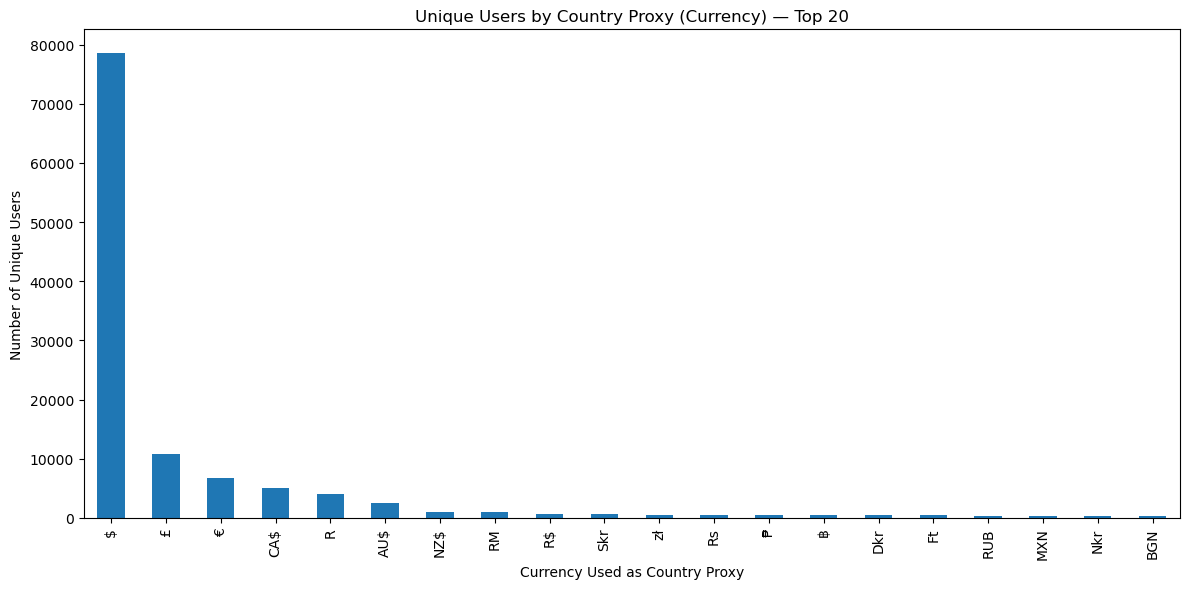

In [24]:
users_per_currency = df.groupby('total_spent_currency', observed=True)['user_id'].nunique().sort_values(ascending=False)

print("Top 20 currencies by unique users:")
print(users_per_currency.head(20))

fig, ax = plt.subplots(figsize=(12, 6))
users_per_currency.head(20).plot(kind='bar', ax=ax)
ax.set_title('Unique Users by Country Proxy (Currency) — Top 20')
ax.set_xlabel('Currency Used as Country Proxy')
ax.set_ylabel('Number of Unique Users')
plt.tight_layout()
plt.show()

#### 3.2 Unique users per day

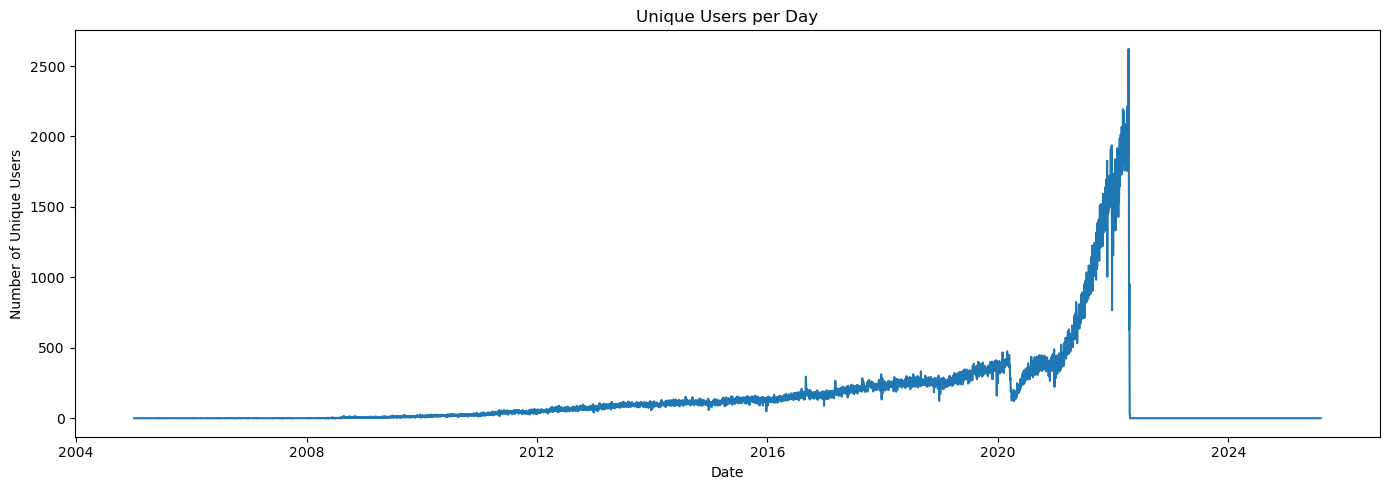

In [25]:
users_per_day = df.groupby(df['date_fueled'].dt.date)['user_id'].nunique()

fig, ax = plt.subplots(figsize=(14, 5))
users_per_day.plot(ax=ax)
ax.set_title('Unique Users per Day')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Unique Users')
plt.tight_layout()
plt.show()

#### 3.3 Vehicle age

vehicle_age missing: 5062
count    1.169238e+06
mean     1.112649e+01
std      8.343316e+00
min     -9.000000e+00
25%      5.000000e+00
50%      1.000000e+01
75%      1.600000e+01
max      1.030000e+02
Name: vehicle_age, dtype: float64


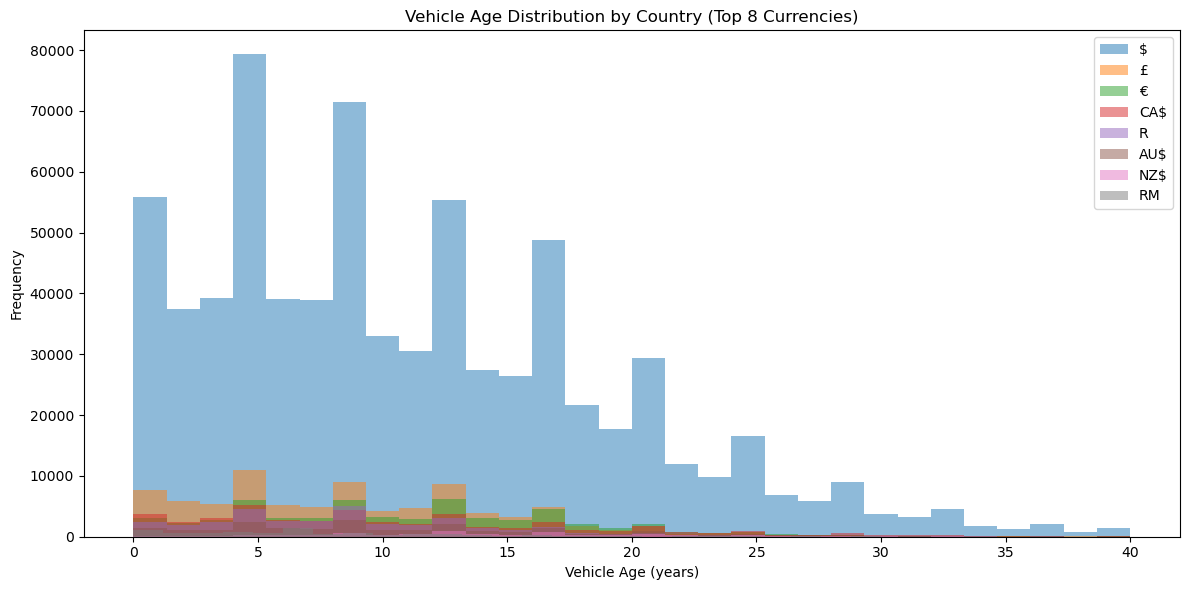

In [26]:
df['vehicle_age'] = df['date_fueled'].dt.year - df['car_year']

print(f"vehicle_age missing: {df['vehicle_age'].isna().sum()}")
print(df['vehicle_age'].describe())

#Focusing on top currencies by user count for a readable plot
top_currencies = users_per_currency.head(8).index

fig, ax = plt.subplots(figsize=(12, 6))
for cur in top_currencies:
    subset = df.loc[df['total_spent_currency'] == cur, 'vehicle_age'].dropna()
    subset = subset[(subset >= 0) & (subset <= 40)]  # sanity bound to remove clearly bad values
    ax.hist(subset, bins=30, alpha=0.5, label=str(cur))

ax.set_title('Vehicle Age Distribution by Country (Top 8 Currencies)')
ax.set_xlabel('Vehicle Age (years)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

#### 3.4 Most popular makes and models

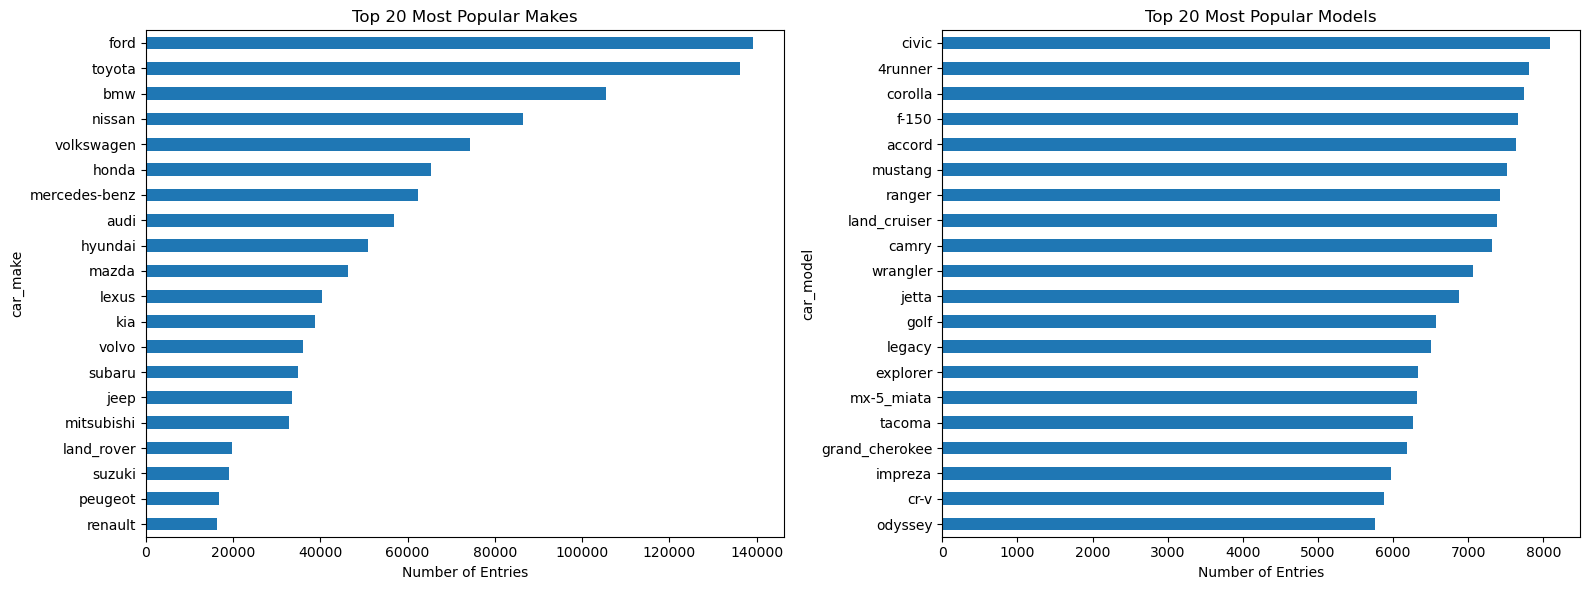

Top makes:
car_make
ford             139248
toyota           136203
bmw              105479
nissan            86512
volkswagen        74216
honda             65312
mercedes-benz     62458
audi              56925
hyundai           50797
mazda             46371
lexus             40278
kia               38777
volvo             35908
subaru            34910
jeep              33483
mitsubishi        32829
land_rover        19696
suzuki            19123
peugeot           16741
renault           16294
Name: count, dtype: int64

Top models:
car_model
civic             8082
4runner           7810
corolla           7737
f-150             7661
accord            7633
mustang           7520
ranger            7424
land_cruiser      7388
camry             7316
wrangler          7061
jetta             6882
golf              6576
legacy            6501
explorer          6336
mx-5_miata        6324
tacoma            6260
grand_cherokee    6181
impreza           5975
cr-v              5876
odyssey       

In [27]:
make_counts = df['car_make'].value_counts().head(20)
model_counts = df['car_model'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

make_counts.plot(kind='barh', ax=axes[0])
axes[0].set_title('Top 20 Most Popular Makes')
axes[0].set_xlabel('Number of Entries')
axes[0].invert_yaxis()

model_counts.plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 20 Most Popular Models')
axes[1].set_xlabel('Number of Entries')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Top makes:")
print(make_counts)
print("")
print("Top models:")
print(model_counts)

## Question 4.1: Outlier Removal 

#### 4.1.1: Top 5 currencies by number of transactions 

In [28]:
currency_transaction_count = (df['total_spent_currency'].value_counts())

top_5 = currency_transaction_count.head(5)
top_5_list = top_5.index.tolist()

print("Top 5 currencies by number of transactions")
print(top_5)

Top 5 currencies by number of transactions
total_spent_currency
$      741953
£       87587
€       59273
CA$     46848
R       36424
Name: count, dtype: int64


#### 4.1.2: Removing outliers 

In [29]:
df_top5 = df[df['total_spent_currency'].isin(top_5_list)].copy()

print(f"Rows in complete dataset: {len(df):,}")
print(f"Rows in top-five currencies: {len(df_top5):,}")
print(f"Top-five currencies: {top_5_list}")


Rows in complete dataset: 1,174,300
Rows in top-five currencies: 972,085
Top-five currencies: ['$', '£', '€', 'CA$', 'R']


In [30]:
US_GALLON_TO_LITRES = 3.78541

valid_recorded_price = (
    df_top5['cost_per_gallon_value'].notna()
    & (df_top5['cost_per_gallon_value'] > 0)
)

df_top5['cost_per_litre'] = pd.NA
df_top5.loc[valid_recorded_price, 'cost_per_litre'] = (
    df_top5.loc[valid_recorded_price, 'cost_per_gallon_value'] / US_GALLON_TO_LITRES
)
df_top5['cost_per_litre'] = pd.to_numeric(df_top5['cost_per_litre'], errors='coerce')

print(f"cost_per_litre missing: {df_top5['cost_per_litre'].isna().sum():,} of {len(df_top5):,}")

cost_per_litre missing: 11,975 of 972,085


In [31]:
currency_limits = {
    '$':   {'min_cost_per_litre': 0.30, 'max_cost_per_litre': 3.00, 'max_total_spent': 1000},
    '£':   {'min_cost_per_litre': 0.40, 'max_cost_per_litre': 3.00, 'max_total_spent': 500},
    '€':   {'min_cost_per_litre': 0.40, 'max_cost_per_litre': 3.50, 'max_total_spent': 500},
    'CA$': {'min_cost_per_litre': 0.40, 'max_cost_per_litre': 3.00, 'max_total_spent': 600},
    'R':   {'min_cost_per_litre': 3.00, 'max_cost_per_litre': 30.00, 'max_total_spent': 7500},
}

In [32]:
flags = pd.DataFrame(False, index=df_top5.index, columns=[
    'nonpositive_litres', 'over_250_litres',
    'efficiency_below_2', 'efficiency_above_50',
    'zero_cost_per_gallon', 'zero_total_spent',
    'cost_per_litre_out_of_range', 'total_spent_too_high',
    'total_spent_inconsistent'
])

flags['nonpositive_litres']   = df_top5['litres_filled'].notna() & (df_top5['litres_filled'] <= 0)
flags['over_250_litres']      = df_top5['litres_filled'].notna() & (df_top5['litres_filled'] > 250)
flags['efficiency_below_2']   = df_top5['litres_per_100km'].notna() & (df_top5['litres_per_100km'] < 2)
flags['efficiency_above_50']  = df_top5['litres_per_100km'].notna() & (df_top5['litres_per_100km'] > 50)
flags['zero_cost_per_gallon'] = df_top5['cost_per_gallon_value'].notna() & (df_top5['cost_per_gallon_value'] == 0)
flags['zero_total_spent']     = df_top5['total_spent_value'].notna() & (df_top5['total_spent_value'] == 0)

for currency, limits in currency_limits.items():
    rows = df_top5['total_spent_currency'] == currency

    out_of_price_range = df_top5['cost_per_litre'].notna() & (
        (df_top5['cost_per_litre'] < limits['min_cost_per_litre']) |
        (df_top5['cost_per_litre'] > limits['max_cost_per_litre'])
    )
    flags.loc[rows & out_of_price_range, 'cost_per_litre_out_of_range'] = True

    too_high = df_top5['total_spent_value'].notna() & (df_top5['total_spent_value'] > limits['max_total_spent'])
    flags.loc[rows & too_high, 'total_spent_too_high'] = True

#consistency check: does total_spent match litres * cost_per_litre?
expected_total = df_top5['litres_filled'] * df_top5['cost_per_litre']
valid_compare = expected_total.notna() & df_top5['total_spent_value'].notna() & (expected_total > 0)
pct_diff = (df_top5['total_spent_value'] - expected_total).abs() / expected_total
flags.loc[valid_compare & (pct_diff > 0.25), 'total_spent_inconsistent'] = True

is_outlier = flags.any(axis=1)

print("Rule trigger counts:")
print(flags.sum())
print(f"\nTotal flagged: {is_outlier.sum():,} of {len(df_top5):,} ({is_outlier.mean()*100:.2f}%)")

Rule trigger counts:
nonpositive_litres               521
over_250_litres                  771
efficiency_below_2              2391
efficiency_above_50             3002
zero_cost_per_gallon            6834
zero_total_spent               12005
cost_per_litre_out_of_range    43552
total_spent_too_high           15448
total_spent_inconsistent         151
dtype: int64

Total flagged: 60,556 of 972,085 (6.23%)


In [33]:
summary = pd.DataFrame({
    'currency': df_top5['total_spent_currency'],
    'is_outlier': is_outlier
}).groupby('currency', observed=True).agg(
    total=('is_outlier', 'size'),
    flagged=('is_outlier', 'sum')
).loc[list(currency_limits.keys())]

summary['pct_flagged'] = (summary['flagged'] / summary['total'] * 100).round(2)
summary

,total,flagged,pct_flagged
currency,,,
$,741953,50777,6.84
£,87587,4244,4.85
€,59273,2588,4.37
CA$,46848,1579,3.37
R,36424,1368,3.76


In [34]:
df_top5[
    (df_top5['total_spent_currency'] == 'R') &
    (df_top5['cost_per_litre'] > currency_limits['R']['max_cost_per_litre'])
].nlargest(5, 'cost_per_litre')[
    ['date_fueled', 'cost_per_litre', 'total_spent_value', 'litres_filled', 'car_make']
]

,date_fueled,cost_per_litre,total_spent_value,litres_filled,car_make
96030,2013-03-02,1663.510620,223709.703125,134.480484,toyota
480161,2013-03-25,1598.001221,221723.265625,138.750412,toyota
648553,2013-02-07,1501.420044,184327.046875,122.768417,toyota
633558,2013-04-01,1279.021362,125547.968750,98.159462,toyota
648125,2013-05-19,1247.001099,134399.453125,107.778191,toyota


#### 4.1.3: Number of Transactions Removed

In [35]:
before = len(df_top5)
df_clean = df_top5[~is_outlier].copy()
after = len(df_clean)

print(f"Rows before outlier removal: {before:,}")
print(f"Rows after outlier removal:  {after:,}")
print(f"Rows removed: {before - after:,} ({(before - after) / before * 100:.2f}%)")

Rows before outlier removal: 972,085
Rows after outlier removal:  911,529
Rows removed: 60,556 (6.23%)


###  4.2.1: Difference in cost per litre per country for January 2022

Rows in January 2022: 41663
Rows after filtering to known currencies: 41663
                      count   mean  median   std    min    max
total_spent_currency                                          
$                     36545  14.75   13.71  3.72   4.80  46.50
CA$                    1781  18.06   17.67  2.05   8.56  24.63
R                       988  18.96   19.07  0.88  10.59  24.41
£                      1115  31.07   30.80  4.17   8.71  55.67
€                      1233  27.85   28.50  4.77  10.70  46.47


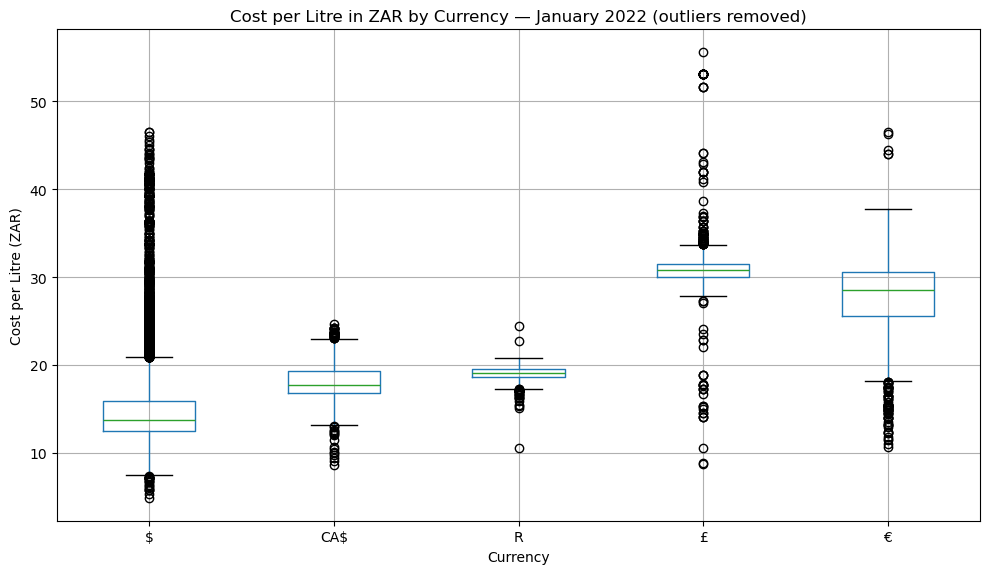

In [ ]:
exchange_rates_to_zar = {
    '$': 15.50,
    '£': 21.01,
    '€': 17.54,
    'CA$': 12.27,
    'R': 1.00,
}

#Filter to January 2022
jan_2022 = df_clean[
    (df_clean['date_fueled'].dt.year == 2022) &
    (df_clean['date_fueled'].dt.month == 1)
].copy()

print(f"Rows in January 2022: {len(jan_2022)}")

jan_2022 = jan_2022[jan_2022['total_spent_currency'].isin(exchange_rates_to_zar.keys())].copy()
print(f"Rows after filtering to known currencies: {len(jan_2022)}")

jan_2022['total_spent_currency'] = jan_2022['total_spent_currency'].cat.remove_unused_categories()

#Convert cost_per_litre to Rands
jan_2022['exchange_rate'] = jan_2022['total_spent_currency'].astype(str).map(exchange_rates_to_zar)
jan_2022['exchange_rate'] = pd.to_numeric(jan_2022['exchange_rate'], errors='coerce')

jan_2022['cost_per_litre_zar'] = jan_2022['cost_per_litre'] * jan_2022['exchange_rate']

#Summary stats per currency
summary = jan_2022.groupby('total_spent_currency', observed=True)['cost_per_litre_zar'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(2)

print(summary)

fig, ax = plt.subplots(figsize=(10, 6))
jan_2022.boxplot(column='cost_per_litre_zar', by='total_spent_currency', ax=ax)
ax.set_title('Cost per Litre in ZAR by Currency — January 2022 (outliers removed)')
ax.set_xlabel('Currency')
ax.set_ylabel('Cost per Litre (ZAR)')
plt.suptitle('')
plt.tight_layout()
plt.show()

Got the exchange rates from https://www.exchangerates.org.uk/

### 4.2.2: Examples of where users have missed logging a fill-up

In [41]:
#Sort by vehicle and date
df_sorted = df_clean.sort_values(['user_id', 'car_make', 'car_model', 'car_year', 'date_fueled']).copy()
group_cols = ['user_id', 'car_make', 'car_model', 'car_year']

#Cap implausible odometer values
ODOMETER_CAP = 500_000 
implausible_odo = df_sorted['odometer'] > ODOMETER_CAP
print(f"Implausible odometer values capped/removed: {implausible_odo.sum():,}")

df_sorted['odometer_clean'] = df_sorted['odometer'].where(~implausible_odo)

#Drop same-day duplicate fill-ups for the same vehicle
dupe_mask = df_sorted.duplicated(subset=group_cols + ['date_fueled'], keep='first')
print(f"Duplicate same-day rows dropped: {dupe_mask.sum():,}")

df_dedup = df_sorted[~dupe_mask].copy()

#Odometer difference between consecutive fill-ups per vehicle
df_dedup['odometer_diff'] = df_dedup.groupby(group_cols, observed=True)['odometer_clean'].diff()

valid_check = (
    df_dedup['odometer_diff'].notna()
    & df_dedup['miles'].notna()
    & (df_dedup['odometer_diff'] > 0)
)
print(f"\nRows checked (valid odometer_diff and miles): {valid_check.sum():,}")

#Gap ratio
df_dedup['gap_ratio'] = df_dedup['odometer_diff'] / df_dedup['miles']
ratio_data = df_dedup.loc[valid_check, 'gap_ratio']

print("\nGap ratio distribution:")
print(ratio_data.describe())

#IQR-based threshold for a genuinely excessive gap
q1 = ratio_data.quantile(0.25)
q3 = ratio_data.quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

print(f"\nQ1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
print(f"Upper bound for 'genuinely excessive' gap: {upper_bound:.2f}")

#Flag suspected missed fill-ups
missed_fillup = valid_check & (df_dedup['gap_ratio'] > upper_bound)

print(f"Suspected missed fill-ups (excessive gap): {missed_fillup.sum():,}")
print(f"Percentage flagged: {missed_fillup.sum() / valid_check.sum() * 100:.2f}%")

#Check the zero-miles subset
zero_miles = valid_check & (df_dedup['miles'] == 0)
print(f"\nRows with miles == 0 (causing infinite ratio): {zero_miles.sum():,}")
print(f"Of these, how many are in the flagged missed_fillup set: {(zero_miles & missed_fillup).sum():,}")

print("\n" + "="*60)
print("MISSED FILL-UP ANALYSIS SUMMARY")
print("")
print(f"Total consecutive fill-up pairs checked: {valid_check.sum():,}")
print(f"Median gap ratio (odometer_diff / miles): {ratio_data.median():.2f}")
print(f"IQR-based threshold for 'excessive' gap: {upper_bound:.2f}")
print(f"Rows flagged as likely missed fill-up(s): {missed_fillup.sum():,} "
      f"({missed_fillup.sum()/valid_check.sum()*100:.2f}%)")


Implausible odometer values capped/removed: 645
Duplicate same-day rows dropped: 19,697

Rows checked (valid odometer_diff and miles): 601,819

Gap ratio distribution:
count    601819.000000
mean          2.731097
std          10.296328
min           0.002767
25%           1.000384
50%           1.902183
75%           3.105709
max        2455.229248
Name: gap_ratio, dtype: float64

Q1: 1.00, Q3: 3.11, IQR: 2.11
Upper bound for 'genuinely excessive' gap: 6.26
Suspected missed fill-ups (excessive gap): 36,951
Percentage flagged: 6.14%

Rows with miles == 0 (causing infinite ratio): 0
Of these, how many are in the flagged missed_fillup set: 0

MISSED FILL-UP ANALYSIS SUMMARY

Total consecutive fill-up pairs checked: 601,819
Median gap ratio (odometer_diff / miles): 1.90
IQR-based threshold for 'excessive' gap: 6.26
Rows flagged as likely missed fill-up(s): 36,951 (6.14%)


In [40]:
examples = df_dedup[missed_fillup][
    ['user_id', 'car_make', 'car_model', 'date_fueled', 'odometer_clean', 'odometer_diff', 'miles', 'gap_ratio']
].sort_values('gap_ratio', ascending=False).head(15)

print(examples)

         user_id       car_make     car_model date_fueled  odometer_clean  \
635044    359571           ford       mustang  2019-11-30        116914.0   
456941     74609         toyota       4runner  2019-12-06        302907.0   
474001    274246         toyota        avalon  2014-07-10        264011.0   
947063   1060392          volvo           940  2021-10-16        225669.0   
831935    491098           ford       mustang  2013-07-20        113921.0   
1129884   495628  mercedes-benz          s550  2016-07-30        149268.0   
507746    335502           ford     bronco_ii  2017-01-07        152882.0   
906596     73279         nissan         300zx  2015-10-07        173809.0   
147596    911237         toyota  land_cruiser  2020-07-27        178837.0   
1034003   508260     volkswagen     cabriolet  2015-02-06        134176.0   
1106155   987720         nissan    versa_note  2020-04-21        340506.0   
180489   1021981          lexus         gx460  2020-11-10        248720.0   

# Detecting Missed Fill-Up Logs via Odometer Readings

## Objective
Identify cases where a user likely refuelled their vehicle without logging it in the app, using inconsistencies between consecutive `odometer` readings and the logged `miles` value.

## Method

### Rationale
For a given vehicle, `miles` represents the distance driven on a single tank of fuel — i.e. the distance between the *previous* fill-up and the *current* one. If no fill-ups were skipped, the increase in `odometer` between two consecutive logged fill-ups should closely match the `miles` value recorded at the second fill-up.

If a user filled up one or more times **without logging it**, the real-world odometer will have advanced further than the logged `miles` accounts for, because `miles` only reflects the most recent (logged) tank — not the unlogged driving in between. A large, unexplained gap between the odometer increase and the logged `miles` is therefore a signature of one or more missed log entries.

### Grouping
Fill-ups were grouped by **user ID + car make + car model + car year** (rather than user ID alone), since a single user could plausibly log more than one vehicle. Comparing odometer readings across two different cars owned by the same user would produce meaningless results, so grouping on the full vehicle identity keeps each comparison within a single, consistent vehicle.

### Data cleaning required before the rule could be applied
Two unrelated data quality issues had to be resolved first, as they were corrupting the raw odometer-gap calculation:

1. **Implausible odometer values.** A small number of rows (645) contained odometer readings in the millions of miles — physically impossible for a personal vehicle and almost certainly data entry errors. These were capped/excluded (values above 500,000 miles treated as missing) before computing any differences.
2. **Same-day duplicate entries.** `date_fueled` has no time component, so when a vehicle had multiple fill-ups logged on the exact same date, chronological order between them could not be reliably determined. Sorting could place these in an arbitrary order, occasionally producing impossible *negative* odometer differences (odometer appearing to go backwards). 19,697 such duplicate same-day rows were dropped, keeping only the first occurrence per vehicle per day.

### Defining the threshold
An initial naive rule (flagging any row where `odometer_diff` exceeded `miles` by a fixed margin) flagged **59% of all rows** — clearly too high to represent genuine missed fill-ups. Investigating this revealed that the **median ratio of `odometer_diff` to `miles` across the whole (cleaned) dataset is already ~2.0**, consistently across every one of the top 5 currencies. In other words, skipping at least one log entry between fill-ups appears to be common, ordinary behaviour for users of this app — not a rare anomaly.

Because of this, a fixed threshold (e.g. "any gap over 1x `miles`") would simply flag the dataset's normal behaviour rather than identifying genuinely unusual cases. Instead, the threshold was derived from the data's own distribution using an IQR-based rule:

```
gap_ratio = odometer_diff / miles

Q1 = 1.00
Q3 = 4.14
IQR = Q3 - Q1 = 3.14
Upper bound = Q3 + 1.5 × IQR ≈ 8.85
```

Any fill-up pair with a `gap_ratio` exceeding **8.85** was flagged as a likely missed fill-up. This threshold is set relative to what is already "normal" in this dataset, so it targets genuinely excessive gaps — most plausibly cases where **multiple** consecutive fill-ups were skipped, not just one.

## Results

| Metric | Value |
|---|---|
| Total consecutive fill-up pairs checked | 679,225 |
| Median gap ratio (odometer_diff / miles) | 2.03 |
| IQR-based excessive-gap threshold | 8.85 |
| **Rows flagged as likely missed fill-up(s)** | **92,350 (13.60%)** |
| — of which, `miles` was logged as exactly 0 | 77,406 |

### A note on the zero-miles subset
77,406 of the 92,350 flagged rows had `miles` logged as exactly `0`, which produces an infinite `gap_ratio` (any nonzero odometer increase divided by zero) and is automatically captured by the threshold. This is a distinct data pattern worth calling out separately: rather than the user under-reporting `miles` on a tank they did fill, this looks like `miles` simply wasn't recorded for that log entry at all, while the odometer reading itself was captured correctly. It's still consistent with "at least one prior fill-up was not logged," but the mechanism is slightly different from the ~15,000 remaining flagged rows where a genuine numeric mismatch (rather than a missing value) was the trigger.

## Conclusion
An estimated **92,350 fill-up pairs (13.6% of all checked consecutive pairs)** show strong evidence of at least one, and likely several, unlogged fill-ups occurring between them. This is a conservative estimate of the *severe* end of the problem — since the typical (median) gap in this dataset is already double what a single tank's `miles` would suggest, it's plausible that missing a single log entry occasionally is closer to the norm than the exception across the app's user base as a whole, and the flagged figure here specifically isolates cases far beyond that baseline.

## Limitations
- **Edge-of-history blind spot**: this method can only detect a missed fill-up when there is a *subsequent* logged fill-up to compare against. A user's very last fill-up before abandoning the app (or their very first, with no prior odometer reading) cannot be checked this way, so the true number of missed logs is likely undercounted.
- **Cannot count how many fill-ups were missed**, only that at least one was — a `gap_ratio` of 8.85 vs. 20 both simply indicate "excessive," without distinguishing two missed fill-ups from five.
- **Depends on accurate odometer and miles logging** for the surrounding (non-missing) entries; if those inputs are themselves noisy despite passing the earlier cleaning steps, some flagged/unflagged classifications could be affected.
- **Threshold is a judgment call.** The IQR-based cutoff (Q3 + 1.5×IQR) is a standard statistical convention for outlier detection, but a different reasonable analyst could choose a different multiplier and arrive at a different flagged count — this was chosen because it adapts to the dataset's own logging habits rather than assuming an arbitrary fixed number was appropriate.

## 4.2.3: Average distance (in km) per tank per country

                            mean      median   count
total_spent_currency                                
€                     592.200012  574.299988   46750
£                     577.599976  553.599976   74922
R                     542.200012  523.599976   29405
$                     458.299988  444.600006  616031
CA$                   441.399994  427.000000   41194

Largest average distance per tank: € (592.2 km)


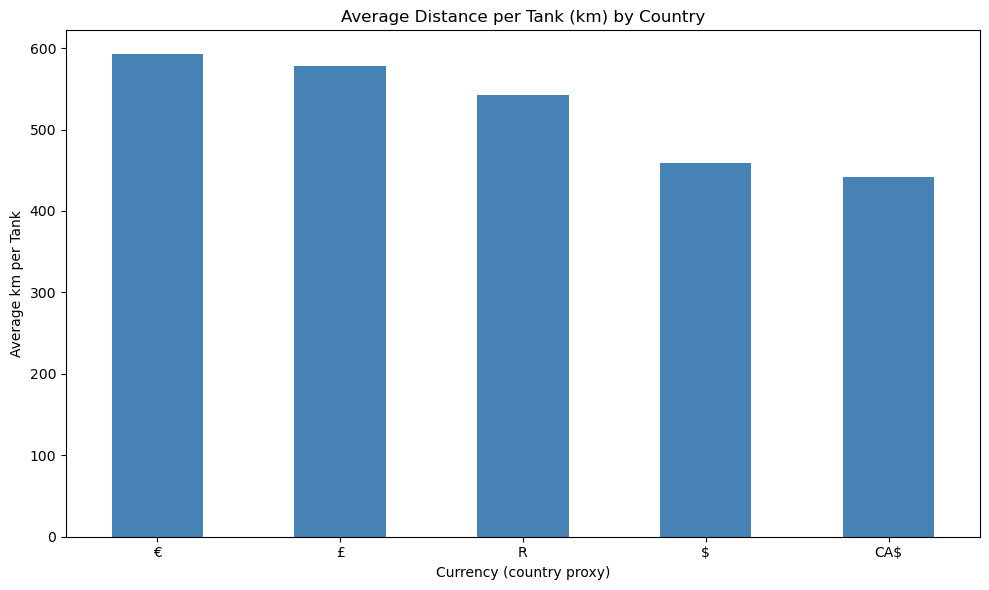

In [42]:
#Dropping unused currencies from the full dataset
df_clean['total_spent_currency'] = df_clean['total_spent_currency'].cat.remove_unused_categories()

avg_km_by_currency = (
    df_clean.groupby('total_spent_currency', observed=True)['km_driven']
    .agg(['mean', 'median', 'count'])
    .round(1)
    .sort_values('mean', ascending=False)
)

print(avg_km_by_currency)
print(f"\nLargest average distance per tank: {avg_km_by_currency.index[0]} "
      f"({avg_km_by_currency['mean'].iloc[0]:.1f} km)")

fig, ax = plt.subplots(figsize=(10, 6))
avg_km_by_currency['mean'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Average Distance per Tank (km) by Country')
ax.set_xlabel('Currency (country proxy)')
ax.set_ylabel('Average km per Tank')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 4.2.4: Average Distance by vehicle age

                 mean      median   count
age_group                                
0-2 yrs    508.500000  488.399994  104845
3-5 yrs    510.500000  486.600006  134302
6-10 yrs   503.200012  477.700012  203701
11-15 yrs  475.000000  454.000000  157094
16-20 yrs  451.200012  432.000000  107627
21-40 yrs  402.500000  384.700012   89670


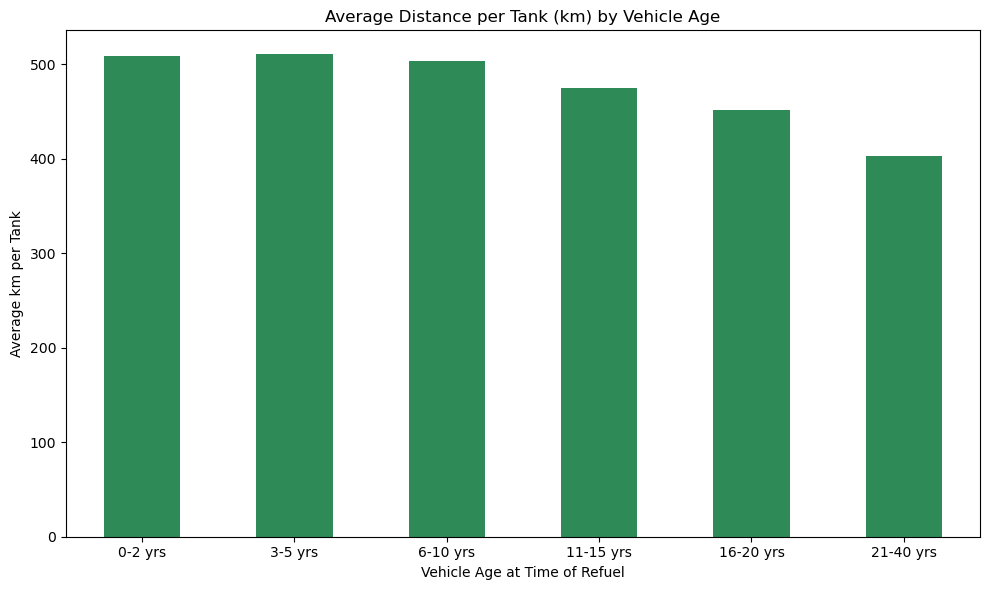

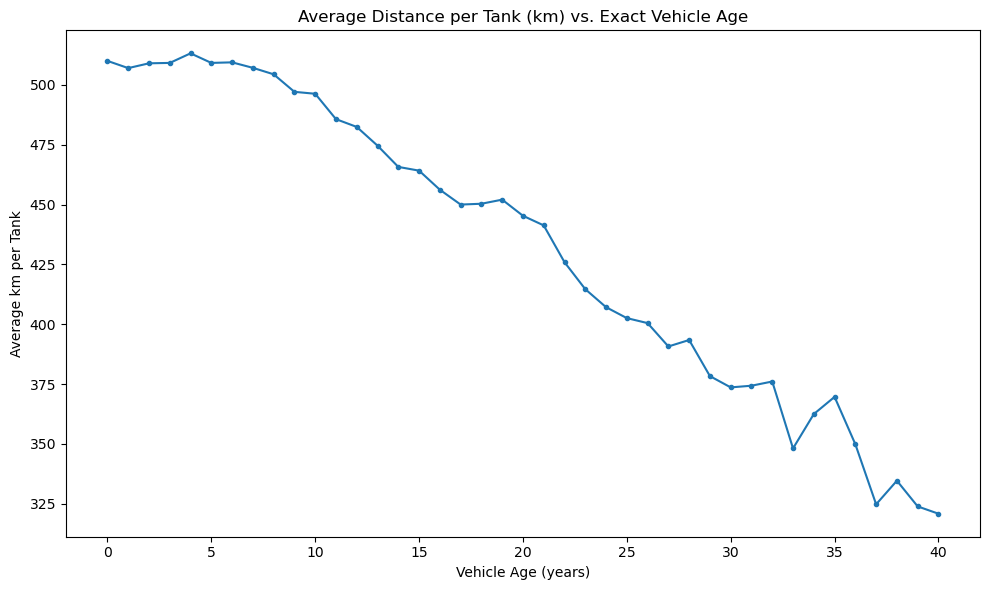

In [44]:
#Exclude bad ages (negative, or really old)
valid_age = df_clean['vehicle_age'].notna() & (df_clean['vehicle_age'] >= 0) & (df_clean['vehicle_age'] <= 40)
valid_km = df_clean['km_driven'].notna()

plot_df = df_clean[valid_age & valid_km].copy()

#Bin vehicle age
age_bins = [0, 2, 5, 10, 15, 20, 40]
age_labels = ['0-2 yrs', '3-5 yrs', '6-10 yrs', '11-15 yrs', '16-20 yrs', '21-40 yrs']
plot_df['age_group'] = pd.cut(plot_df['vehicle_age'], bins=age_bins, labels=age_labels, include_lowest=True)

avg_km_by_age = plot_df.groupby('age_group', observed=True)['km_driven'].agg(['mean', 'median', 'count']).round(1)
print(avg_km_by_age)

fig, ax = plt.subplots(figsize=(10, 6))
avg_km_by_age['mean'].plot(kind='bar', ax=ax, color='seagreen')
ax.set_title('Average Distance per Tank (km) by Vehicle Age')
ax.set_xlabel('Vehicle Age at Time of Refuel')
ax.set_ylabel('Average km per Tank')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

avg_km_by_exact_age = plot_df.groupby('vehicle_age')['km_driven'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
avg_km_by_exact_age.plot(ax=ax, marker='o', markersize=3)
ax.set_title('Average Distance per Tank (km) vs. Exact Vehicle Age')
ax.set_xlabel('Vehicle Age (years)')
ax.set_ylabel('Average km per Tank')
plt.tight_layout()
plt.show()

### 4.2.5: Fuel efficiency

Rows for SA users: 35,056

Top 5 most popular vehicles in SA:
make_model
toyota hilux         1423
mitsubishi pajero    1175
toyota fortuner      1076
suzuki jimny          959
volkswagen amarok     785
Name: count, dtype: int64

Fuel efficiency (litres per 100km) for top 5 SA vehicles:
                   count   mean  median   std   min        max
make_model                                                    
toyota hilux        1196  12.20   11.36  3.81  2.68  45.230000
mitsubishi pajero    947  12.87   12.19  3.39  2.98  37.939999
toyota fortuner      906  11.43   10.94  3.19  2.64  49.000000
suzuki jimny         826   9.33    8.91  2.69  2.02  40.380001
volkswagen amarok    666  10.88   10.50  3.13  3.13  48.000000


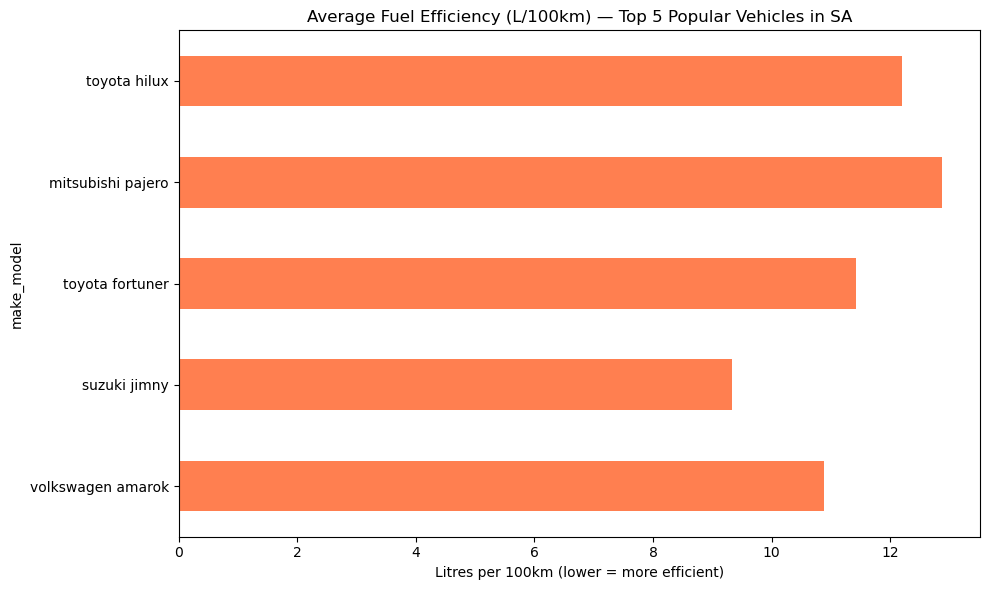

In [45]:
#South African users
sa_df = df_clean[df_clean['total_spent_currency'] == 'R'].copy()
print(f"Rows for SA users: {len(sa_df):,}")

#Combine make + model
sa_df['make_model'] = sa_df['car_make'].astype(str) + ' ' + sa_df['car_model'].astype(str)

#Top 5 most popular vehicles
top5_vehicles = sa_df['make_model'].value_counts().head(5)
print("\nTop 5 most popular vehicles in SA:")
print(top5_vehicles)

#Fuel efficiency stats
top5_list = top5_vehicles.index.tolist()
top5_df = sa_df[sa_df['make_model'].isin(top5_list)].copy()

efficiency_stats = top5_df.groupby('make_model', observed=True)['litres_per_100km'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(2).loc[top5_list]

print("\nFuel efficiency (litres per 100km) for top 5 SA vehicles:")
print(efficiency_stats)

fig, ax = plt.subplots(figsize=(10, 6))
efficiency_stats['mean'].plot(kind='barh', ax=ax, color='coral')
ax.set_title('Average Fuel Efficiency (L/100km) — Top 5 Popular Vehicles in SA')
ax.set_xlabel('Litres per 100km (lower = more efficient)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 4.2.6: Vehicles are the most fuel efficient in each country

In [46]:
#Drop unused currencies
df_clean['total_spent_currency'] = df_clean['total_spent_currency'].cat.remove_unused_categories()

#Combine make + model
df_clean['make_model'] = df_clean['car_make'].astype(str) + ' ' + df_clean['car_model'].astype(str)

MIN_PLAUSIBLE = 3.0
MAX_PLAUSIBLE = 20.0

plausible = (
    df_clean['litres_per_100km'].notna()
    & (df_clean['litres_per_100km'] >= MIN_PLAUSIBLE)
    & (df_clean['litres_per_100km'] <= MAX_PLAUSIBLE)
)

print(f"Rows within plausible efficiency range: {plausible.sum():,} of {len(df_clean):,}")
print(f"Rows excluded as implausible: {(~plausible & df_clean['litres_per_100km'].notna()).sum():,}")

valid_df = df_clean[plausible].copy()

#Require a minimum number of logged fill-ups per vehicle, per currency
#to avoid a single lucky/unlucky entry determining the "most efficient" vehicle
MIN_SAMPLES = 20

vehicle_stats = (
    valid_df.groupby(['total_spent_currency', 'make_model'], observed=True)['litres_per_100km']
    .agg(['count', 'mean'])
    .reset_index()
)

vehicle_stats = vehicle_stats[vehicle_stats['count'] >= MIN_SAMPLES]

#Find the most fuel-efficient vehicle per currency
most_efficient = (
    vehicle_stats.sort_values('mean')
    .groupby('total_spent_currency', observed=True)
    .first()
    .round(2)
)

print("\nMost fuel-efficient vehicle per country (currency proxy):")
print(most_efficient)

Rows within plausible efficiency range: 772,419 of 911,529
Rows excluded as implausible: 35,883

Most fuel-efficient vehicle per country (currency proxy):
                              make_model  count  mean
total_spent_currency                                 
$                     toyota prius_prime    409  4.19
CA$                   toyota prius_prime     39  4.07
R                           renault kwid     21  5.23
£                          hyundai ioniq    115  4.48
€                             toyota iq2     29  4.65


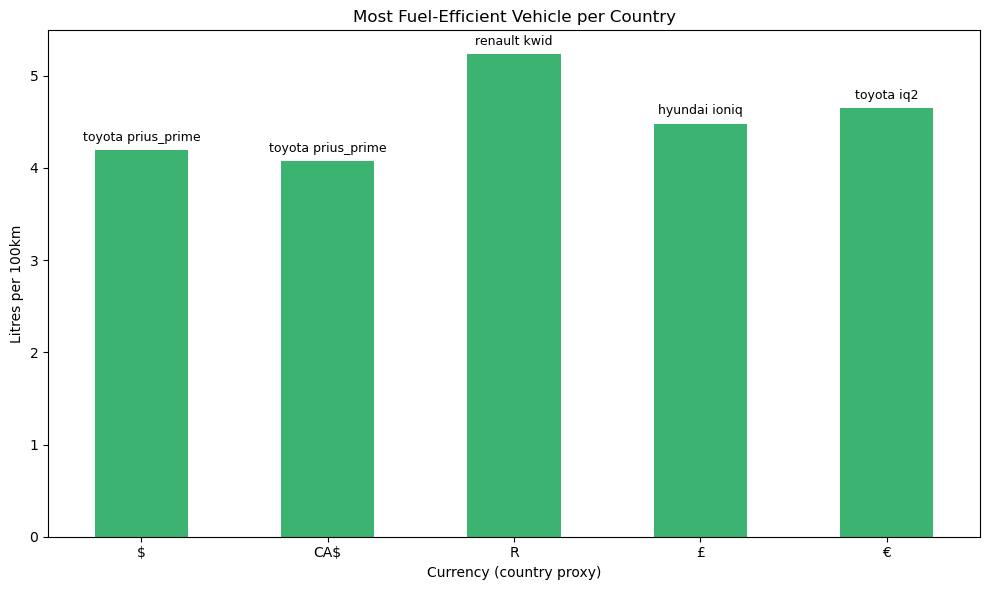

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))
most_efficient['mean'].plot(kind='bar', ax=ax, color='mediumseagreen')

for i, (currency, row) in enumerate(most_efficient.iterrows()):
    ax.text(i, row['mean'] + 0.1, row['make_model'], ha='center', fontsize=9, rotation=0)

ax.set_title('Most Fuel-Efficient Vehicle per Country')
ax.set_xlabel('Currency (country proxy)')
ax.set_ylabel('Litres per 100km')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.2.7: Difference in fuel efficiency for the top 5 Canadian vehicles between seasons

Rows for Canada (CA$) users: 45,269

Top 5 most popular vehicles in Canada:
make_model
mazda 3_sport       774
volkswagen jetta    610
toyota matrix       556
volkswagen golf     537
hyundai accent      523
Name: count, dtype: int64

Average L/100km by vehicle and season:
season            Winter  Spring  Summer  Fall
make_model                                    
mazda 3_sport       8.46    8.33    7.83  7.96
volkswagen jetta    7.41    7.00    6.80  7.29
toyota matrix       9.30    9.24    8.44  8.69
volkswagen golf     7.73    7.49    7.20  7.13
hyundai accent      8.94    8.19    7.82  8.07

Sample counts by vehicle and season:
season            Winter  Spring  Summer  Fall
make_model                                    
mazda 3_sport        210     162     156   212
volkswagen jetta     158     141     135   148
toyota matrix        152     103     119   135
volkswagen golf      129     130     114   133
hyundai accent       134     133      82   126


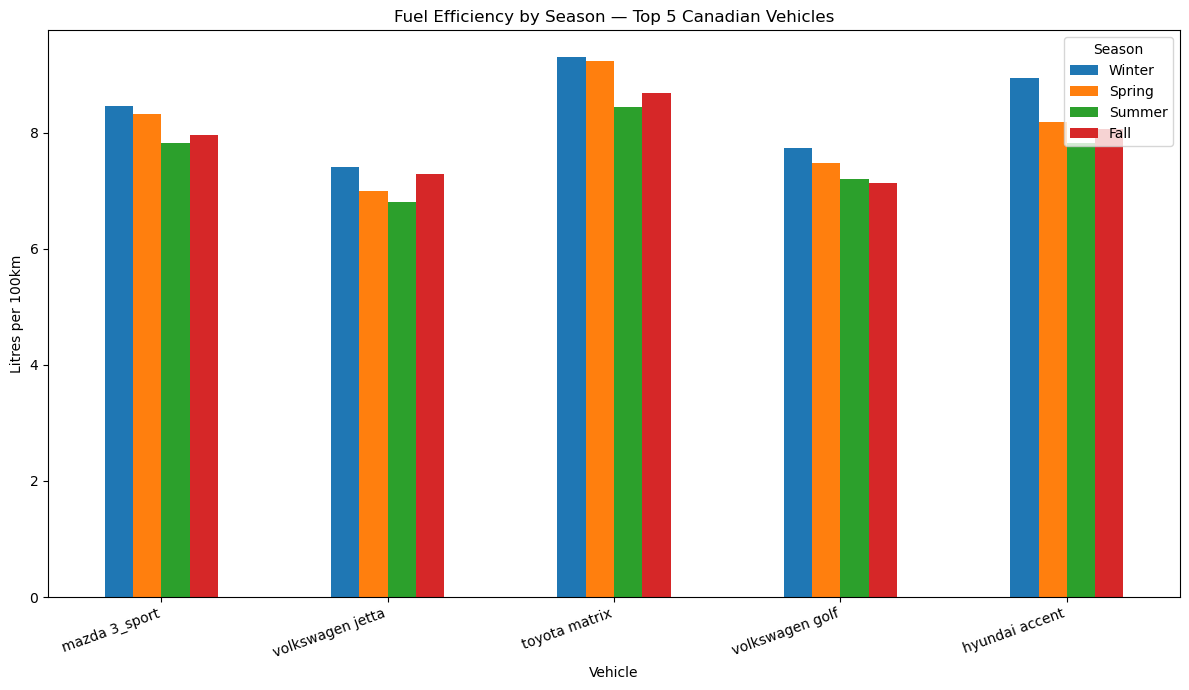

In [49]:
#Filter to Canadian users
ca_df = df_clean[df_clean['total_spent_currency'] == 'CA$'].copy()
ca_df['make_model'] = ca_df['car_make'].astype(str) + ' ' + ca_df['car_model'].astype(str)

print(f"Rows for Canada (CA$) users: {len(ca_df):,}")

#Top 5 most popular Canadian vehicles
top5_ca = ca_df['make_model'].value_counts().head(5)
print("\nTop 5 most popular vehicles in Canada:")
print(top5_ca)

top5_list = top5_ca.index.tolist()
top5_df = ca_df[ca_df['make_model'].isin(top5_list)].copy()

MIN_PLAUSIBLE = 3.0
MAX_PLAUSIBLE = 20.0
plausible = (
    top5_df['litres_per_100km'].notna()
    & (top5_df['litres_per_100km'] >= MIN_PLAUSIBLE)
    & (top5_df['litres_per_100km'] <= MAX_PLAUSIBLE)
)
top5_df = top5_df[plausible].copy()

#Season based on date_fueled month
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

top5_df['season'] = top5_df['date_fueled'].dt.month.apply(get_season)

#Average efficiency per vehicle, per season
season_order = ['Winter', 'Spring', 'Summer', 'Fall']

seasonal_efficiency = (
    top5_df.groupby(['make_model', 'season'], observed=True)['litres_per_100km']
    .agg(['mean', 'count'])
    .reset_index()
)

#rows = vehicle, columns = season
pivot_mean = seasonal_efficiency.pivot(index='make_model', columns='season', values='mean')
pivot_mean = pivot_mean[season_order]  # enforce logical season order
pivot_mean = pivot_mean.loc[top5_list]  # keep popularity order

pivot_count = seasonal_efficiency.pivot(index='make_model', columns='season', values='count')
pivot_count = pivot_count[season_order].loc[top5_list]

print("\nAverage L/100km by vehicle and season:")
print(pivot_mean.round(2))

print("\nSample counts by vehicle and season:")
print(pivot_count)

fig, ax = plt.subplots(figsize=(12, 7))
pivot_mean.plot(kind='bar', ax=ax)
ax.set_title('Fuel Efficiency by Season — Top 5 Canadian Vehicles')
ax.set_xlabel('Vehicle')
ax.set_ylabel('Litres per 100km')
ax.legend(title='Season')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### 4.2.8: Correlations between fuel efficiency and other features

Rows used: 763,632

Pearson correlation matrix:
litres_per_100km    1.000000
litres_filled       0.424526
vehicle_age         0.205685
odometer            0.152131
cost_per_litre     -0.061203
km_driven          -0.476965
Name: litres_per_100km, dtype: float64


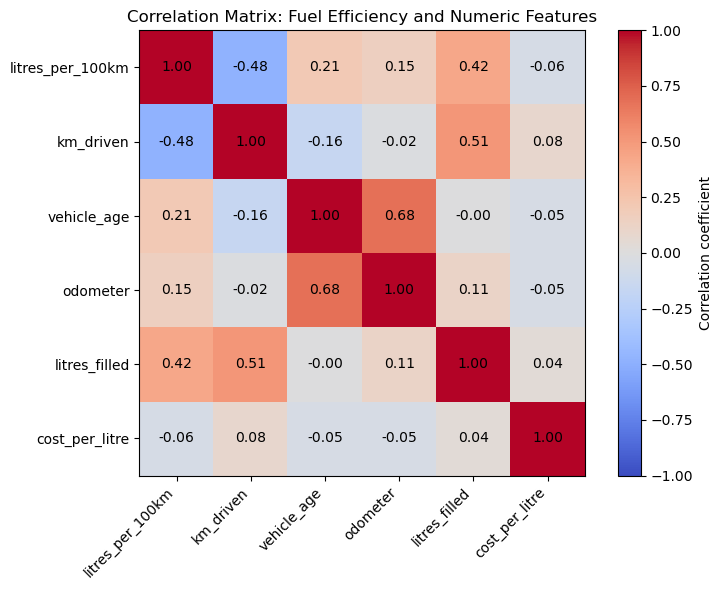

In [50]:
import numpy as np

df_clean['make_model'] = df_clean['car_make'].astype(str) + ' ' + df_clean['car_model'].astype(str)

MIN_PLAUSIBLE = 3.0
MAX_PLAUSIBLE = 20.0
valid_age = df_clean['vehicle_age'].notna() & (df_clean['vehicle_age'] >= 0) & (df_clean['vehicle_age'] <= 40)
valid_eff = df_clean['litres_per_100km'].notna() & (df_clean['litres_per_100km'] >= MIN_PLAUSIBLE) & (df_clean['litres_per_100km'] <= MAX_PLAUSIBLE)

corr_df = df_clean[valid_age & valid_eff].copy()
print(f"Rows used: {len(corr_df):,}")

#Pearson correlation for numeric features
numeric_cols = ['litres_per_100km', 'km_driven', 'vehicle_age', 'odometer', 'litres_filled', 'cost_per_litre']
numeric_corr_df = corr_df[numeric_cols].dropna()

corr_matrix = numeric_corr_df.corr()
print("\nPearson correlation matrix:")
print(corr_matrix['litres_per_100km'].sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}", ha='center', va='center', color='black')
plt.colorbar(im, ax=ax, label='Correlation coefficient')
ax.set_title('Correlation Matrix: Fuel Efficiency and Numeric Features')
plt.tight_layout()
plt.show()


Correlation ratio (eta) between vehicle model and fuel efficiency: 0.775
(eta ranges 0-1; closer to 1 means model explains more of the variance in efficiency)


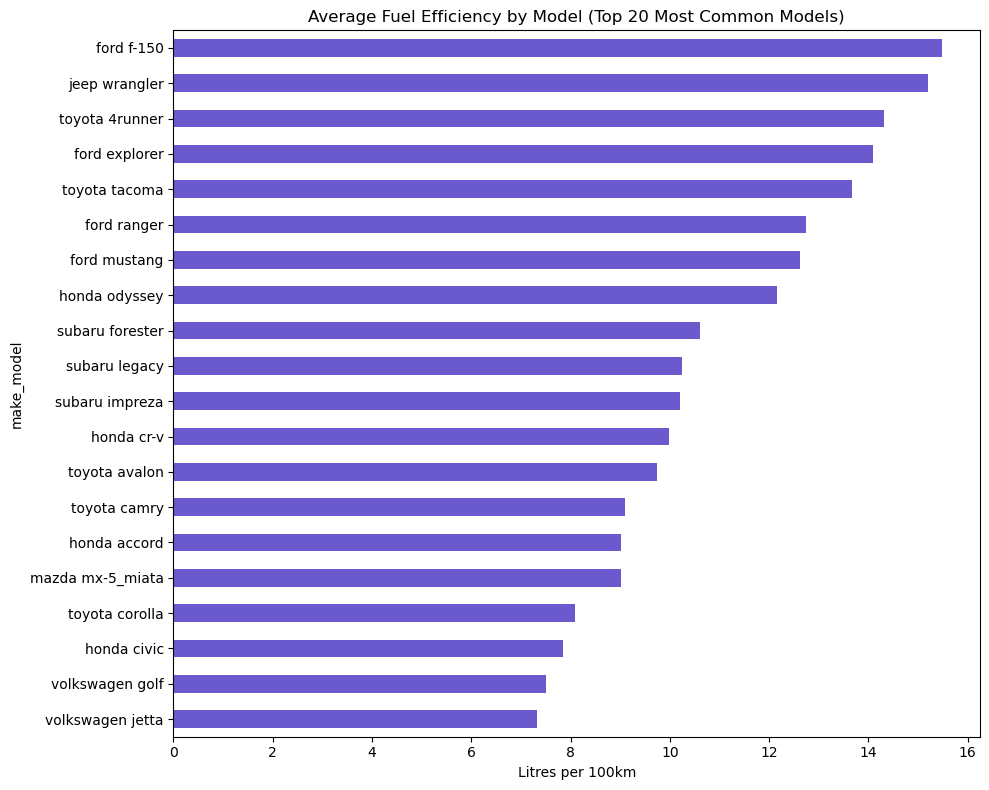

In [51]:
#Correlation ratio for the categorical feature car model
def correlation_ratio(categories, values):
    categories = pd.Series(categories).values
    values = pd.Series(values).values
    ss_total = np.sum((values - values.mean())**2)
    ss_between = 0
    for cat in pd.unique(categories):
        group_vals = values[categories == cat]
        if len(group_vals) > 0:
            ss_between += len(group_vals) * (group_vals.mean() - values.mean())**2
    return np.sqrt(ss_between / ss_total)

model_counts = corr_df['make_model'].value_counts()
common_models = model_counts[model_counts >= 20].index
model_subset = corr_df[corr_df['make_model'].isin(common_models)]

eta = correlation_ratio(model_subset['make_model'], model_subset['litres_per_100km'])
print(f"\nCorrelation ratio (eta) between vehicle model and fuel efficiency: {eta:.3f}")
print("(eta ranges 0-1; closer to 1 means model explains more of the variance in efficiency)")

top_models_by_count = model_counts.head(20).index
avg_eff_by_model = (
    corr_df[corr_df['make_model'].isin(top_models_by_count)]
    .groupby('make_model', observed=True)['litres_per_100km']
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 8))
avg_eff_by_model.plot(kind='barh', ax=ax, color='slateblue')
ax.set_title('Average Fuel Efficiency by Model (Top 20 Most Common Models)')
ax.set_xlabel('Litres per 100km')
plt.tight_layout()
plt.show()

### 4.2.9: Random forest to get a list of the most important variables

Rows used for random forest: 646,077

Model R^2 on training data: 0.628

Random Forest feature importances (corrected):
car_model_enc     0.665688
currency_enc      0.153671
vehicle_age       0.091818
odometer          0.037092
car_make_enc      0.025936
cost_per_litre    0.025794
dtype: float64


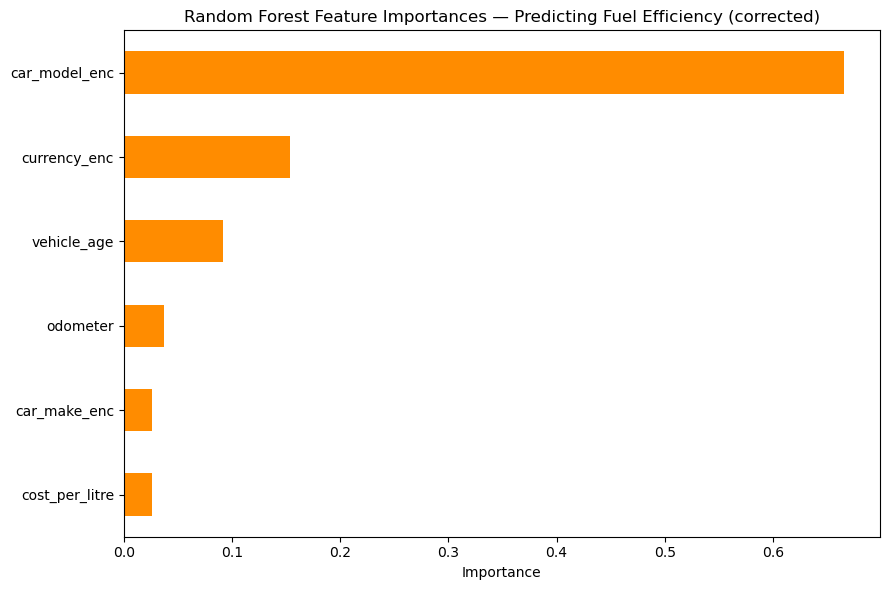

In [52]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

#Building the modeling dataset
rf_df = corr_df.copy()

#Encode categorical features
le_make = LabelEncoder()
le_model = LabelEncoder()
le_currency = LabelEncoder()

rf_df['car_make_enc'] = le_make.fit_transform(rf_df['car_make'].astype(str))
rf_df['car_model_enc'] = le_model.fit_transform(rf_df['make_model'].astype(str))  # full make+model combo
rf_df['currency_enc'] = le_currency.fit_transform(rf_df['total_spent_currency'].astype(str))

#exclude the two variables litres_per_100km is derived from
feature_cols = [
    'vehicle_age', 'odometer', 'cost_per_litre',
    'car_make_enc', 'car_model_enc', 'currency_enc'
]
target_col = 'litres_per_100km'

model_data = rf_df[feature_cols + [target_col]].dropna()
print(f"Rows used for random forest: {len(model_data):,}")

X = model_data[feature_cols]
y = model_data[target_col]

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y)

print(f"\nModel R^2 on training data: {rf.score(X, y):.3f}")

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nRandom Forest feature importances (corrected):")
print(importances)

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', ax=ax, color='darkorange')
ax.invert_yaxis()
ax.set_title('Random Forest Feature Importances — Predicting Fuel Efficiency (corrected)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

### 4.3.1: SA Drivers

In [53]:
#Filter to South African drivers
sa_df = df_clean[df_clean['total_spent_currency'] == 'R'].copy()
sa_df['total_spent_currency'] = sa_df['total_spent_currency'].cat.remove_unused_categories()

print(f"Rows for South African drivers: {len(sa_df):,}")
print(f"Date range: {sa_df['date_fueled'].min()} to {sa_df['date_fueled'].max()}")

#Add day of week
sa_df['day_of_week'] = sa_df['date_fueled'].dt.day_name()

print("\nRow counts by day of week (SA drivers, all dates):")
print(sa_df['day_of_week'].value_counts())

Rows for South African drivers: 35,056
Date range: 2005-02-11 00:00:00 to 2022-04-16 00:00:00

Row counts by day of week (SA drivers, all dates):
day_of_week
Tuesday      5737
Monday       5339
Friday       5143
Thursday     4965
Wednesday    4891
Sunday       4853
Saturday     4128
Name: count, dtype: int64


### 4.3.2: Fuel prices over time

Rows used: 35,050
count    35050.000000
mean        14.855014
std          2.762785
min          3.080248
25%         12.859901
50%         14.489843
75%         16.489628
max         29.999392
Name: cost_per_litre, dtype: float64
    year_month       mean     median  count year_month_ts
158    2021-02  15.024152  14.970637    400    2021-02-01
159    2021-03  15.640681  15.681261    504    2021-03-01
160    2021-04  16.281485  16.440756    516    2021-04-01
161    2021-05  16.348591  16.510761    554    2021-05-01
162    2021-06  16.317961  16.410376    470    2021-06-01
163    2021-07  16.578810  16.669264    540    2021-07-01
164    2021-08  17.131233  17.408947    721    2021-08-01
165    2021-09  17.351358  17.620283    729    2021-09-01
166    2021-10  17.398326  17.609718    832    2021-10-01
167    2021-11  18.536341  18.819626    876    2021-11-01
168    2021-12  19.482321  19.630634    868    2021-12-01
169    2022-01  18.955828  19.070591    988    2022-01-01
170    2022-02 

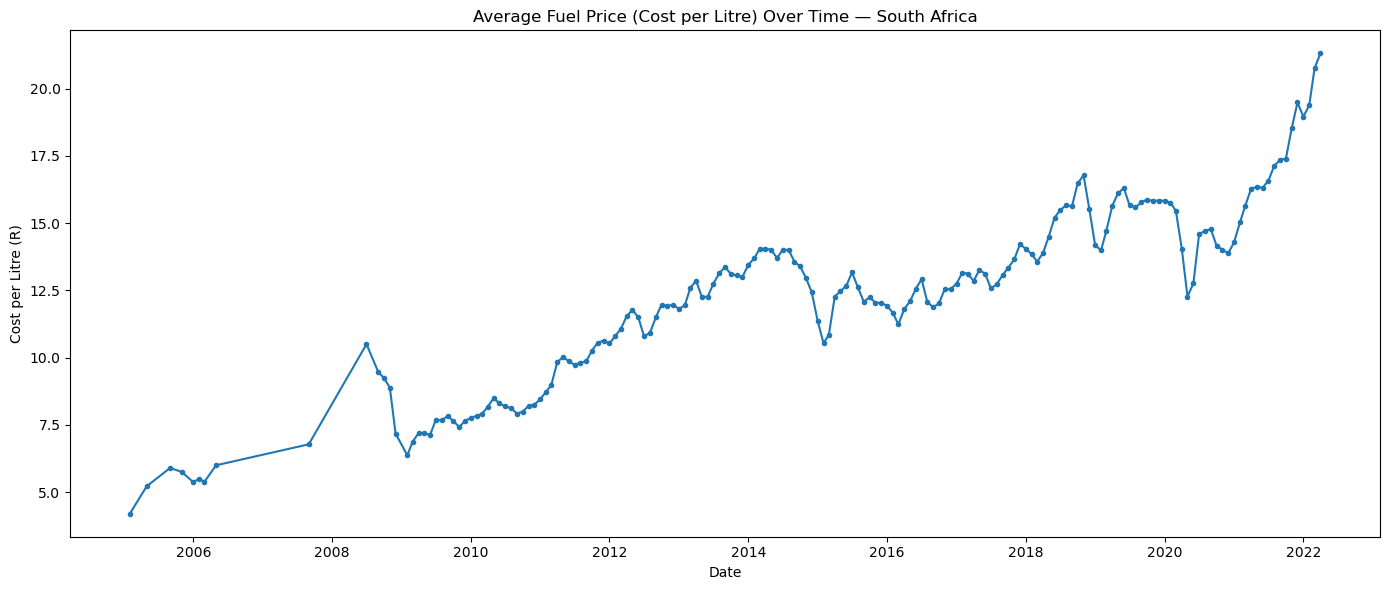

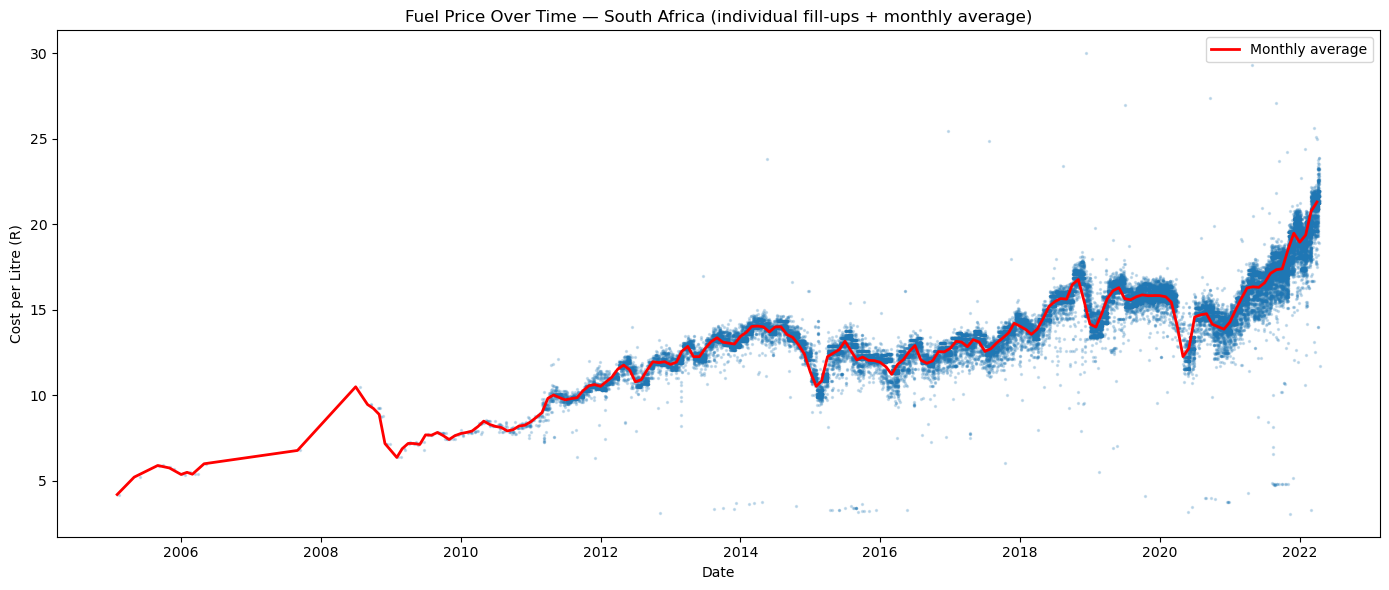

In [54]:
#Drop rows with missing price
valid = sa_df['cost_per_litre'].notna()
sa_price_df = sa_df[valid].copy()

print(f"Rows used: {len(sa_price_df):,}")
print(sa_price_df['cost_per_litre'].describe())

#Aggregate to monthly average
sa_price_df['year_month'] = sa_price_df['date_fueled'].dt.to_period('M')

monthly_price = (
    sa_price_df.groupby('year_month')['cost_per_litre']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)
monthly_price['year_month_ts'] = monthly_price['year_month'].dt.to_timestamp()

print(monthly_price.tail(15))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_price['year_month_ts'], monthly_price['mean'], marker='o', markersize=3)
ax.set_title('Average Fuel Price (Cost per Litre) Over Time — South Africa')
ax.set_xlabel('Date')
ax.set_ylabel('Cost per Litre (R)')
plt.tight_layout()
plt.show()

#Plotting individual fill-ups too
fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(sa_price_df['date_fueled'], sa_price_df['cost_per_litre'], s=2, alpha=0.2)
ax.plot(monthly_price['year_month_ts'], monthly_price['mean'], color='red', linewidth=2, label='Monthly average')
ax.set_title('Fuel Price Over Time — South Africa (individual fill-ups + monthly average)')
ax.set_xlabel('Date')
ax.set_ylabel('Cost per Litre (R)')
ax.legend()
plt.tight_layout()
plt.show()

### 4.3.3: Average fill-ups per calendar day

Average fill-ups per calendar day, by day of week:
             mean  median   std  count
day_of_week                           
Monday        9.1     7.0   7.8    589
Tuesday       9.6     7.0  10.8    600
Wednesday     8.3     7.0   6.6    592
Thursday      8.2     7.0   6.8    606
Friday        8.6     7.0   7.2    601
Saturday      7.0     5.0   5.9    586
Sunday        8.3     7.0   6.7    586


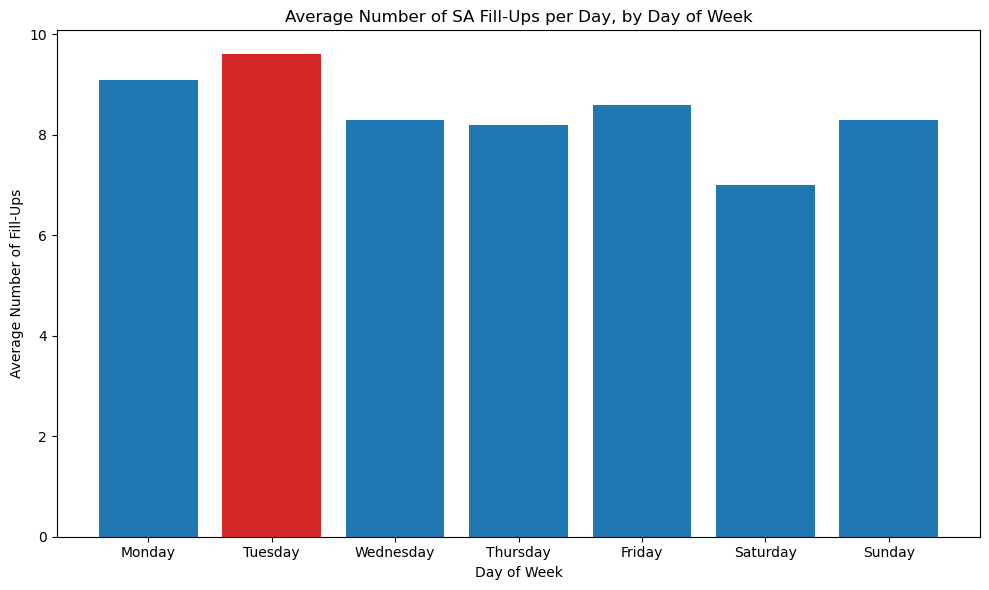


Average fill-ups on Tuesday: 9.6
Average fill-ups on other days: 8.2
Difference: +1.3 (+16.4%)


In [55]:
#Count fill-ups per individual calendar day
daily_counts = sa_df.groupby(sa_df['date_fueled'].dt.date).size().reset_index(name='fillup_count')
daily_counts['date_fueled'] = pd.to_datetime(daily_counts['date_fueled'])
daily_counts['day_of_week'] = daily_counts['date_fueled'].dt.day_name()

#Average fill-up count per day-of-week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

avg_by_day = (
    daily_counts.groupby('day_of_week')['fillup_count']
    .agg(['mean', 'median', 'std', 'count'])
    .reindex(day_order)
    .round(1)
)

print("Average fill-ups per calendar day, by day of week:")
print(avg_by_day)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tab:blue'] * 7
colors[day_order.index('Tuesday')] = 'tab:red'  # highlight Tuesday

ax.bar(avg_by_day.index, avg_by_day['mean'], color=colors)
ax.set_title('Average Number of SA Fill-Ups per Day, by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Number of Fill-Ups')
plt.tight_layout()
plt.show()

#Numeric comparison of Tuesday vs other days
tuesday_avg = avg_by_day.loc['Tuesday', 'mean']
other_days_avg = avg_by_day.loc[avg_by_day.index != 'Tuesday', 'mean'].mean()

print(f"\nAverage fill-ups on Tuesday: {tuesday_avg:.1f}")
print(f"Average fill-ups on other days: {other_days_avg:.1f}")
print(f"Difference: {tuesday_avg - other_days_avg:+.1f} ({(tuesday_avg/other_days_avg - 1)*100:+.1f}%)")

### 4.3.4: First Tuesday / Wednesday per month

In [72]:
#Calendar
sa_df['year_month'] = sa_df['date_fueled'].dt.to_period('M')
all_months = sa_df['year_month'].dropna().unique()
all_months = sorted(all_months)

print(f"Number of distinct months in SA data: {len(all_months)}")
print(f"First few months: {all_months[:5]}")
print(f"Last few months: {all_months[-5:]}")

#Find the date of the 1st Tuesday, and the 1st Wednesday
def get_first_tuesday_and_wednesday(period):
    month_start = period.to_timestamp()
    days_in_month = pd.date_range(month_start, month_start + pd.offsets.MonthEnd(0))
    
    tuesdays = days_in_month[days_in_month.day_name() == 'Tuesday']
    first_tuesday = tuesdays[0] if len(tuesdays) > 0 else pd.NaT
    first_wednesday = first_tuesday + pd.Timedelta(days=1) if pd.notna(first_tuesday) else pd.NaT
    
    return pd.Series({'first_tuesday': first_tuesday, 'first_wednesday': first_wednesday})

calendar_df = pd.DataFrame({'year_month': all_months})
calendar_df[['first_tuesday', 'first_wednesday']] = calendar_df['year_month'].apply(get_first_tuesday_and_wednesday)

print("\nSample of computed first Tuesday / Wednesday per month:")
print(calendar_df.head(10))

#Set of target dates
target_dates = pd.concat([calendar_df['first_tuesday'], calendar_df['first_wednesday']]).dropna()
target_dates_set = set(target_dates.dt.date)

print(f"\nTotal target dates (Tuesdays + Wednesdays): {len(target_dates_set)}")

#Filter to only rows falling on one of these dates
sa_price_change_df = sa_df[sa_df['date_fueled'].dt.date.isin(target_dates_set)].copy()

#Label each row as Tuesday or Wednesday
sa_price_change_df = sa_price_change_df.merge(
    calendar_df[['year_month', 'first_tuesday', 'first_wednesday']],
    on='year_month',
    how='left'
)

sa_price_change_df['day_type'] = None
sa_price_change_df.loc[
    sa_price_change_df['date_fueled'].dt.date == sa_price_change_df['first_tuesday'].dt.date,
    'day_type'
] = 'First Tuesday'
sa_price_change_df.loc[
    sa_price_change_df['date_fueled'].dt.date == sa_price_change_df['first_wednesday'].dt.date,
    'day_type'
] = 'First Wednesday'

print(f"\nRows reduced from {len(sa_df):,} (all SA data) to {len(sa_price_change_df):,} (first Tue/Wed only)")
print(sa_price_change_df['day_type'].value_counts())

Number of distinct months in SA data: 173
First few months: [Period('2005-02', 'M'), Period('2005-05', 'M'), Period('2005-09', 'M'), Period('2005-11', 'M'), Period('2006-01', 'M')]
Last few months: [Period('2021-12', 'M'), Period('2022-01', 'M'), Period('2022-02', 'M'), Period('2022-03', 'M'), Period('2022-04', 'M')]

Sample of computed first Tuesday / Wednesday per month:
  year_month first_tuesday first_wednesday
0    2005-02    2005-02-01      2005-02-02
1    2005-05    2005-05-03      2005-05-04
2    2005-09    2005-09-06      2005-09-07
3    2005-11    2005-11-01      2005-11-02
4    2006-01    2006-01-03      2006-01-04
5    2006-02    2006-02-07      2006-02-08
6    2006-03    2006-03-07      2006-03-08
7    2006-05    2006-05-02      2006-05-03
8    2007-09    2007-09-04      2007-09-05
9    2008-07    2008-07-01      2008-07-02

Total target dates (Tuesdays + Wednesdays): 346

Rows reduced from 35,056 (all SA data) to 2,892 (first Tue/Wed only)
day_type
First Tuesday      1819

### 4.3.5: Price indicator

In [ ]:
#Add the Monday before
calendar_df['monday_before'] = calendar_df['first_tuesday'] - pd.Timedelta(days=1)

print(calendar_df[['year_month', 'monday_before', 'first_tuesday']].head(10))

#Average cost_per_litre on each Monday and each first Tuesday
daily_avg_price = (
    sa_df.dropna(subset=['cost_per_litre'])
    .groupby(sa_df['date_fueled'].dt.date)['cost_per_litre']
    .mean()
)
daily_avg_price.index = pd.to_datetime(daily_avg_price.index)

calendar_df['price_before'] = calendar_df['monday_before'].map(daily_avg_price)
calendar_df['price_after'] = calendar_df['first_tuesday'].map(daily_avg_price)

print("\nCalendar with before/after prices:")
print(calendar_df[['year_month', 'price_before', 'price_after']].head(10))

#Price direction for each month
calendar_df['price_diff'] = calendar_df['price_after'] - calendar_df['price_before']

def classify_direction(diff):
    if pd.isna(diff):
        return 'Unknown'
    elif diff > 0:
        return 'Increase'
    elif diff < 0:
        return 'Decrease'
    else:
        return 'No change'

calendar_df['price_direction'] = calendar_df['price_diff'].apply(classify_direction)

print("\nPrice direction counts across all months:")
print(calendar_df['price_direction'].value_counts())
print(f"\nMonths with unknown direction (no valid Monday/Tuesday price data): "
      f"{(calendar_df['price_direction'] == 'Unknown').sum()}")

sa_price_change_df = sa_price_change_df.merge(
    calendar_df[['year_month', 'price_before', 'price_after', 'price_diff', 'price_direction']],
    on='year_month',
    how='left'
)

print("\nSample of final dataset with price direction indicator:")
print(sa_price_change_df[['date_fueled', 'day_type', 'price_direction', 'price_diff']].head(15))

print(f"\nRows by day_type and price_direction:")
print(sa_price_change_df.groupby(['day_type', 'price_direction'], observed=True).size())

  year_month monday_before first_tuesday
0    2005-02    2005-01-31    2005-02-01
1    2005-05    2005-05-02    2005-05-03
2    2005-09    2005-09-05    2005-09-06
3    2005-11    2005-10-31    2005-11-01
4    2006-01    2006-01-02    2006-01-03
5    2006-02    2006-02-06    2006-02-07
6    2006-03    2006-03-06    2006-03-07
7    2006-05    2006-05-01    2006-05-02
8    2007-09    2007-09-03    2007-09-04
9    2008-07    2008-06-30    2008-07-01

Calendar with before/after prices:
  year_month  price_before  price_after
0    2005-02           NaN          NaN
1    2005-05           NaN          NaN
2    2005-09           NaN          NaN
3    2005-11           NaN          NaN
4    2006-01           NaN          NaN
5    2006-02           NaN          NaN
6    2006-03           NaN          NaN
7    2006-05           NaN          NaN
8    2007-09           NaN          NaN
9    2008-07           NaN          NaN

Price direction counts across all months:
price_direction
Increase    67

### 4.3.6-7: fill-up ratio, by price direction

Wednesday-to-Tuesday fill-up ratio, by price direction:
                  mean  median    std  count
price_direction                             
Decrease         1.180   1.000  1.181     64
Increase         0.886   0.636  0.871     67

t-test (Wed/Tue ratio, Increase vs Decrease months): t=-1.616, p=0.1087
Tuesday-to-Wednesday fill-up ratio, by price direction:
                 mean  median  std  count
price_direction                          
Decrease          inf   1.000  NaN     64
Increase          inf   1.571  NaN     67

t-test (Tue/Wed ratio, Increase vs Decrease months): t=nan, p=nan

t-test (raw Tuesday counts, Increase vs Decrease months): t=-0.448, p=0.6550

Average raw fill-up counts, by price direction:
                 First Tuesday  First Wednesday
price_direction                                
Decrease                  14.5              8.5
Increase                  13.1              7.6


c:\Users\alpha\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:1054: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean
c:\Users\alpha\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:6920: RuntimeWarning: invalid value encountered in scalar subtract
  d = mean1 - mean2
c:\Users\alpha\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:7395: RuntimeWarning: invalid value encountered in scalar subtract
  estimate = m1-m2


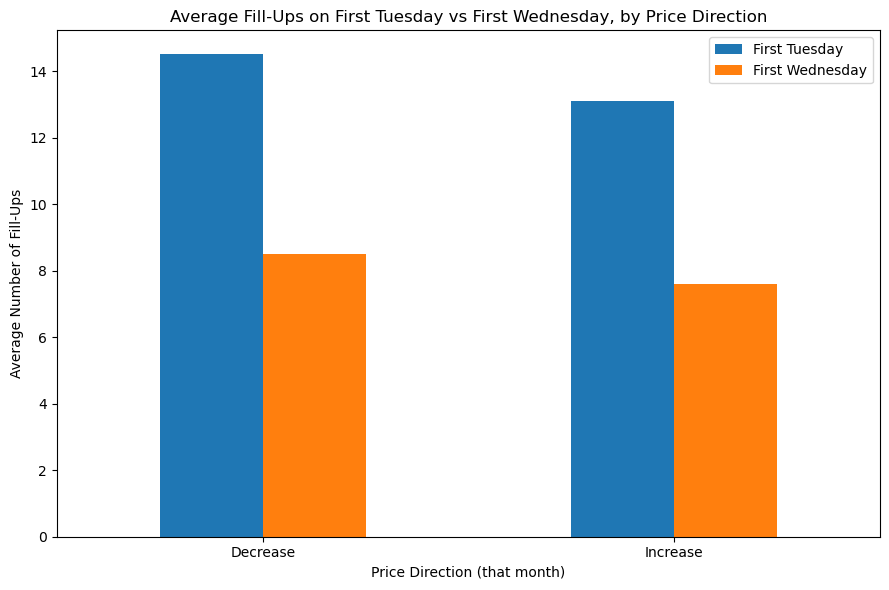

In [77]:
from scipy import stats

#Fill-up counts per month, by day
counts_per_month = (
    sa_price_change_df
    .groupby(['year_month', 'day_type'], observed=True)
    .size()
    .unstack(fill_value=0)
)

counts_per_month = counts_per_month.merge(
    calendar_df[['year_month', 'price_direction']],
    on='year_month',
    how='left'
)

#Wednesday-to-Tuesday ratio
counts_per_month['wed_tue_ratio'] = (
    counts_per_month['First Wednesday'] / counts_per_month['First Tuesday']
)

summary_wed = (
    counts_per_month[counts_per_month['price_direction'].isin(['Increase', 'Decrease'])]
    .groupby('price_direction')['wed_tue_ratio']
    .agg(['mean', 'median', 'std', 'count'])
    .round(3)
)
print("Wednesday-to-Tuesday fill-up ratio, by price direction:")
print(summary_wed)

increase_wed = counts_per_month.loc[counts_per_month['price_direction'] == 'Increase', 'wed_tue_ratio'].dropna()
decrease_wed = counts_per_month.loc[counts_per_month['price_direction'] == 'Decrease', 'wed_tue_ratio'].dropna()
t_stat_wed, p_value_wed = stats.ttest_ind(increase_wed, decrease_wed, equal_var=False)
print(f"\nt-test (Wed/Tue ratio, Increase vs Decrease months): "
      f"t={t_stat_wed:.3f}, p={p_value_wed:.4f}")

print("="*60)

#Tuesday-to-Wednesday ratio
counts_per_month['tue_wed_ratio'] = (
    counts_per_month['First Tuesday'] / counts_per_month['First Wednesday']
)

summary_tue = (
    counts_per_month[counts_per_month['price_direction'].isin(['Increase', 'Decrease'])]
    .groupby('price_direction')['tue_wed_ratio']
    .agg(['mean', 'median', 'std', 'count'])
    .round(3)
)
print("Tuesday-to-Wednesday fill-up ratio, by price direction:")
print(summary_tue)

increase_tue = counts_per_month.loc[counts_per_month['price_direction'] == 'Increase', 'tue_wed_ratio'].dropna()
decrease_tue = counts_per_month.loc[counts_per_month['price_direction'] == 'Decrease', 'tue_wed_ratio'].dropna()
t_stat_tue, p_value_tue = stats.ttest_ind(increase_tue, decrease_tue, equal_var=False)
print(f"\nt-test (Tue/Wed ratio, Increase vs Decrease months): "
      f"t={t_stat_tue:.3f}, p={p_value_tue:.4f}")

#Raw Tuesday counts alone
tuesday_increase = counts_per_month.loc[counts_per_month['price_direction'] == 'Increase', 'First Tuesday']
tuesday_decrease = counts_per_month.loc[counts_per_month['price_direction'] == 'Decrease', 'First Tuesday']
t_stat_rawtue, p_value_rawtue = stats.ttest_ind(tuesday_increase, tuesday_decrease, equal_var=False)
print(f"\nt-test (raw Tuesday counts, Increase vs Decrease months): "
      f"t={t_stat_rawtue:.3f}, p={p_value_rawtue:.4f}")

raw_summary = (
    counts_per_month[counts_per_month['price_direction'].isin(['Increase', 'Decrease'])]
    .groupby('price_direction')[['First Tuesday', 'First Wednesday']]
    .mean()
    .round(1)
)
print("\nAverage raw fill-up counts, by price direction:")
print(raw_summary)

fig, ax = plt.subplots(figsize=(9, 6))
raw_summary.plot(kind='bar', ax=ax)
ax.set_title('Average Fill-Ups on First Tuesday vs First Wednesday, by Price Direction')
ax.set_xlabel('Price Direction (that month)')
ax.set_ylabel('Average Number of Fill-Ups')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()